# ImageCLEFmed Concept Detection Task

## Install Dependencies and Load Dataset

In [ ]:
!pip install -q iterative-stratification

In [ ]:
!cp "/content/drive/MyDrive/dev_concept_with_mapping.zip" "/content/"

!unzip -q "/content/dev_concept_with_mapping.zip" -d "/content/dev_concept_with_mapping"

In [ ]:
import os
import time
import random
import copy
import pickle
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter
import itertools
import json
import re
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from torchvision import transforms, models

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MultiLabelBinarizer

from tqdm import tqdm

In [ ]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

reproducibility()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Random seed set to 42
Using device: cuda


## Specialized Dataset Class, Binarizer and Dataloaders

In [ ]:
class ImageCLEFmedDataset(Dataset):
    def __init__(self, root_dir, mlb, split='train', transform=None, exclude_ids=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.mlb = mlb

        self.image_dir = os.path.join(root_dir, 'images')

        cui_path = os.path.join(root_dir, 'cui_mapping.csv')
        self.cui_mapping = {}
        if os.path.exists(cui_path):
            cui_df = pd.read_csv(cui_path)
            self.cui_mapping = dict(zip(cui_df['CUI'], cui_df['Canonical name']))

        if split == 'test':
            test_path = os.path.join(root_dir, 'test_concepts.csv')
            self.data_df = pd.read_csv(test_path).reset_index(drop=True)
        else:
            concepts_path = os.path.join(root_dir, 'concepts.csv')
            all_concepts_df = pd.read_csv(concepts_path)
            self.data_df = all_concepts_df[
                all_concepts_df['ID'].str.contains(self.split, case=False, na=False)
            ].reset_index(drop=True)

            if split == 'train' and exclude_ids is not None:
                before = len(self.data_df)
                self.data_df = self.data_df[
                    ~self.data_df['ID'].isin(exclude_ids)
                ].reset_index(drop=True)
                print(f"[ImageCLEFmedDataset] Removed {before - len(self.data_df)} test IDs from train split.")

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        row = self.data_df.iloc[idx]
        img_id = row['ID']

        cui_string = row['CUIs']
        cuis = str(cui_string).split(';') if pd.notna(cui_string) else []

        concept_names = [self.cui_mapping.get(cui, cui) for cui in cuis]

        img_name = os.path.join(self.image_dir, f"{img_id}.jpg")

        image = Image.open(img_name).convert('RGB')

        if self.transform:
            image = self.transform(image)

        binary_labels = self.mlb.transform([cuis])[0]
        label_tensor = torch.tensor(binary_labels, dtype=torch.float32)

        return {
            'id': img_id,
            'image': image,
            'labels': label_tensor,
            'cuis': ";".join(cuis),
            'concept_names': ";".join(concept_names)
        }

In [ ]:
dataset_path = '/content/dev_concept_with_mapping/dev_concept'

all_concepts_df = pd.read_csv(f'{dataset_path}/concepts.csv')

test_concepts_df = pd.read_csv(f'{dataset_path}/test_concepts.csv')
test_ids = set(test_concepts_df['ID'].tolist())
print(f"Test samples (from test_concepts.csv): {len(test_ids)}")

train_concepts_df = all_concepts_df[
    all_concepts_df['ID'].str.contains('train', case=False, na=False) &
    ~all_concepts_df['ID'].isin(test_ids)
].reset_index(drop=True)

all_train_cuis = train_concepts_df['CUIs'].dropna().apply(lambda x: str(x).split(';')).tolist()

mlb = MultiLabelBinarizer()
mlb.fit(all_train_cuis)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageCLEFmedDataset(dataset_path, mlb, split='train', transform=transform, exclude_ids=test_ids)
val_dataset   = ImageCLEFmedDataset(dataset_path, mlb, split='valid', transform=transform)
test_dataset  = ImageCLEFmedDataset(dataset_path, mlb, split='test',  transform=transform)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=4)

Test samples (from test_concepts.csv): 7005
[ImageCLEFmedDataset] Removed 7005 test IDs from train split.
Train samples : 90359
Val samples   : 19240
Test samples  : 7005


## Backbone Classes and Function Definitions

In [ ]:
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6, p_trainable=True):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p) if p_trainable else p
        self.eps = eps

    def forward(self, x):
        return nn.functional.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            kernel_size=(x.size(-2), x.size(-1))
        ).pow(1.0 / self.p)

    def __repr__(self):
        p_val = round(self.p.item(), 4) if isinstance(self.p, nn.Parameter) else self.p
        return f"GeM(p={p_val}, eps={self.eps})"

In [ ]:
FEATURE_DIMS = {
    "efficientnet_b0"  : 1280,
    "efficientnet_v2_s": 1280,
    "efficientnet_v2_m": 1280,
    "densenet121"      : 1024,
    "convnext_tiny"    :  768,
    "resnet50"         : 2048
}

def get_backbone(name):
    if name == "efficientnet_b0":
        return models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1).features
    elif name == "efficientnet_v2_s":
        return models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1).features
    elif name == "efficientnet_v2_m":
        return models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1).features
    elif name == "densenet121":
        return models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).features
    elif name == "convnext_tiny":
        return models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1).features
    elif name == "resnet50":
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        return nn.Sequential(*list(backbone.children())[:-2])
    else:
        raise ValueError(f"Unsupported backbone: {name}")

In [ ]:
class ConceptDetectionModel(nn.Module):
    def __init__(self, backbone_name, num_classes, dropout=0.0,
                 pool_type="avg", gem_p=3.0):
        super().__init__()

        self.backbone_name = backbone_name
        self.backbone      = get_backbone(backbone_name)
        num_features       = FEATURE_DIMS[backbone_name]

        if pool_type == "gem":
            self.pool = GeM(p=gem_p, p_trainable=True)
        elif pool_type == "avg":
            self.pool = nn.AdaptiveAvgPool2d(1)
        elif pool_type == "max":
            self.pool = nn.AdaptiveMaxPool2d(1)
        else:
            raise ValueError(f"Unknown pool_type: {pool_type}")

        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.flatten(x)
        return self.classifier(x)

In [ ]:
class ConceptDetectionModel2(nn.Module):
    def __init__(self, backbone_name, num_classes, dropout=0.0,
                 pool_type="gem", gem_p=3.0, hidden_dims=None):
        super().__init__()

        self.backbone_name = backbone_name
        self.backbone      = get_backbone(backbone_name)
        num_features       = FEATURE_DIMS[backbone_name]

        if pool_type == "gem":
            self.pool = GeM(p=gem_p, p_trainable=True)
        elif pool_type == "avg":
            self.pool = nn.AdaptiveAvgPool2d(1)
        elif pool_type == "max":
            self.pool = nn.AdaptiveMaxPool2d(1)
        else:
            raise ValueError(f"Unknown pool_type: {pool_type}")

        self.flatten = nn.Flatten()

        layers = []
        layers.append(nn.Dropout(p=dropout))

        in_features = num_features

        if hidden_dims:

            if isinstance(hidden_dims, int):
                hidden_dims = [hidden_dims]

            for h_dim in hidden_dims:
                layers.append(nn.Linear(in_features, h_dim))
                layers.append(nn.ReLU(inplace=True))
                layers.append(nn.Dropout(p=dropout))
                in_features = h_dim

        layers.append(nn.Linear(in_features, num_classes))

        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.flatten(x)
        return self.classifier(x)

In [ ]:
def official_clef_f1(y_true_matrix: np.ndarray, y_pred_matrix: np.ndarray, mlb) -> float:
    classes = np.array(mlb.classes_)
    total_score = 0.0
    max_score = len(y_true_matrix)

    for gt_row, pred_row in zip(y_true_matrix, y_pred_matrix):
        gt_concepts   = set(classes[gt_row.astype(bool)])
        pred_concepts = set(classes[pred_row.astype(bool)])

        if len(gt_concepts) == 0:
            max_score -= 1
            continue

        all_concepts = sorted(gt_concepts | pred_concepts)
        y_true = [1 if c in gt_concepts   else 0 for c in all_concepts]
        y_pred = [1 if c in pred_concepts else 0 for c in all_concepts]

        total_score += f1_score(y_true, y_pred, average="binary", zero_division=0)

    return total_score / max_score if max_score > 0 else 0.0

In [ ]:
def train_per_epoch(model, loader, optimizer, criterion, device="cuda"):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="Training Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        preds = (torch.sigmoid(logits) > 0.5).int()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1 = official_clef_f1(y_true, y_pred, mlb)

    return epoch_loss, epoch_f1


def evaluate(model, loader, criterion, device="cuda"):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating Batches"):
            x = batch['image'].to(device)
            y = batch['labels'].to(device).float()

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            preds = (torch.sigmoid(logits) > 0.5).int()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1 = official_clef_f1(y_true, y_pred, mlb)

    return epoch_loss, epoch_f1


def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, scheduler=None, patience=3, device="cuda"):
    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_f1 = train_per_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_f1 = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss (Tr/Val): {train_loss:.6f}/{val_loss:.6f} | "
            f"F1 (Tr/Val): {train_f1:.6f}/{val_f1:.6f}"
        )

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1} (best val loss: {best_val_loss:.4f})")
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time

    print("-" * 40)
    print(f"Best Validation F1-Score (Epoch {best_epoch}): {val_f1s[best_epoch-1]:.6f}")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,
        "training_time": training_time,
    }

def plot_train_curves(results, title="", save_path=None):
    best_epoch = results["best_epoch"]
    epochs = range(1, len(results["train_losses"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results["train_losses"], label="Train Loss", color='blue')
    plt.plot(epochs, results["val_losses"], label="Val Loss", color='orange')
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Loss Curves - {title}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results["train_f1s"], label="Train F1", color='blue', linestyle='-')
    plt.plot(epochs, results["val_f1s"], label="Val F1", color='orange', linestyle='-')
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"F1 Score - {title}")
    plt.xlabel("Epochs")
    plt.ylabel("F1 Score (Sample-Averaged)")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved training curves to: {save_path}")

    plt.show()

In [ ]:
def get_probabilities(model, loader, device="cuda"):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting Probs"):
            x = batch['image'].to(device)
            y_primary = batch['labels'].to(device).float()

            logits = model(x)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_primary.cpu().numpy())

    return np.vstack(all_labels), np.vstack(all_probs)

def find_best_global_threshold(y_true, y_prob, start=0.1, end=0.6, steps=51, device="cuda"):
    y_true_t = torch.tensor(y_true, dtype=torch.float32, device=device)
    y_prob_t = torch.tensor(y_prob, dtype=torch.float32, device=device)

    valid_mask = torch.sum(y_true_t, dim=1) > 0

    y_true_t = y_true_t[valid_mask]
    y_prob_t = y_prob_t[valid_mask]

    candidates = torch.linspace(start, end, steps, device=device)

    best_t = 0.5
    best_f1 = 0.0
    all_f1_scores = []

    true_sum = torch.sum(y_true_t, dim=1)

    for t in tqdm(candidates, desc="Testing Global Thresholds"):
        y_pred_t = (y_prob_t >= t).float()

        tp = torch.sum(y_true_t * y_pred_t, dim=1)
        pred_sum = torch.sum(y_pred_t, dim=1)

        denominator = pred_sum + true_sum

        f1_per_sample = torch.where(
            denominator > 0,
            2.0 * tp / denominator,
            torch.zeros_like(tp)
        )

        current_f1 = torch.mean(f1_per_sample).item()
        all_f1_scores.append(current_f1)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_t = t.item()

    print(f"\nOptimal Global Threshold: {best_t:.2f}")
    print(f"\nBest Validation Sample-F1: {best_f1:.6f}")

    return best_t, best_f1, candidates.cpu().numpy(), all_f1_scores

def evaluate_with_threshold(model, loader, criterion, device="cuda", threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating Batches"):
            x = batch['image'].to(device)
            y = batch['labels'].to(device).float()

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            preds = (torch.sigmoid(logits) >= threshold).int()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1 = official_clef_f1(y_true, y_pred, mlb)

    return epoch_loss, epoch_f1

## Training CNN Backbones and Global Threshold Optimization

### EfficientNetB0 Training, Plots and Global Threshold Optimization

In [ ]:
reproducibility(seed=43)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(mlb.classes_)

model_efficientnetb0 = ConceptDetectionModel(
        backbone_name="efficientnet_b0",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model_efficientnetb0.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1
)

print(f"Starting optimized training of EfficientNetB0 on {device} with {num_classes} total classes...")
results_efficientnetb0 = train_model(
    model=model_efficientnetb0,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    scheduler=scheduler,
    patience=3,
    device=device
)

print("-" * 40)
test_loss, test_f1 = evaluate(model_efficientnetb0, test_loader, criterion, device)
print(f"Test F1-Score: {test_f1:.6f}")

Random seed set to 43
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


Starting optimized training of EfficientNetB0 on cuda with 2645 total classes...


Evaluating Batches: 100%|██████████| 1203/1203 [00:43<00:00, 27.84it/s]


Epoch 1/30 | Loss (Tr/Val): 0.006774/0.004856 | F1 (Tr/Val): 0.478001/0.564964


...

Epoch 7/30 | Loss (Tr/Val): 0.003535/0.004312 | F1 (Tr/Val): 0.595156/0.580898


Evaluating Batches: 100%|██████████| 1203/1203 [00:43<00:00, 27.96it/s]


Epoch 8/30 | Loss (Tr/Val): 0.003302/0.004342 | F1 (Tr/Val): 0.602764/0.580398
Early stopping triggered at epoch 8 (best val loss: 0.0043)
----------------------------------------
Best Validation F1-Score (Epoch 5): 0.584099
Training Time: 73.01 minutes
----------------------------------------


Evaluating Batches:  18%|█▊        | 77/438 [00:02<00:11, 31.45it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 30.92it/s]


Test F1-Score: 0.586506


Model weights saved to /content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed43.pth
Saved training curves to: /content/drive/MyDrive/imageclefmed/plots/efficientnetb0_curves1_seed43.png


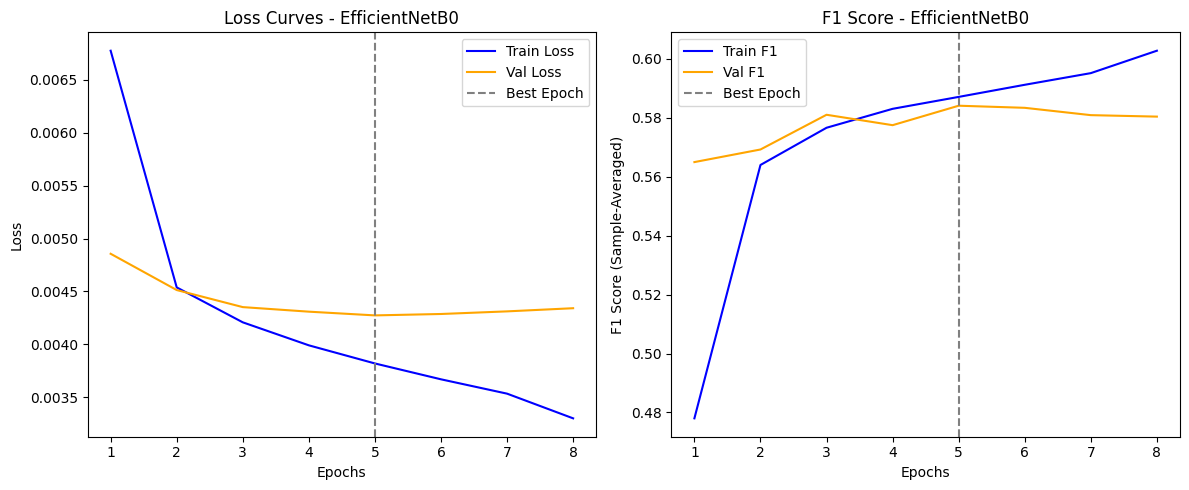

In [ ]:
output_dir_model = "/content/drive/MyDrive/imageclefmed/models"
output_dir_plot = "/content/drive/MyDrive/imageclefmed/plots"

model_save_path = os.path.join(output_dir_model, "efficientnetb0_1_seed43.pth")
torch.save(model_efficientnetb0.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

plot_save_path = os.path.join(output_dir_plot, "efficientnetb0_curves1_seed43.png")
plot_train_curves(results_efficientnetb0, title="EfficientNetB0", save_path=plot_save_path)

Successfully loaded model weights from: /content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed43.pth

Extracting probabilities from the validation set...


Extracting Probs: 100%|██████████| 1203/1203 [00:42<00:00, 28.13it/s]



Optimizing global threshold...


Testing Global Thresholds: 100%|██████████| 51/51 [00:00<00:00, 153.44it/s]



Optimal Global Threshold: 0.43

Best Validation Sample-F1: 0.585242


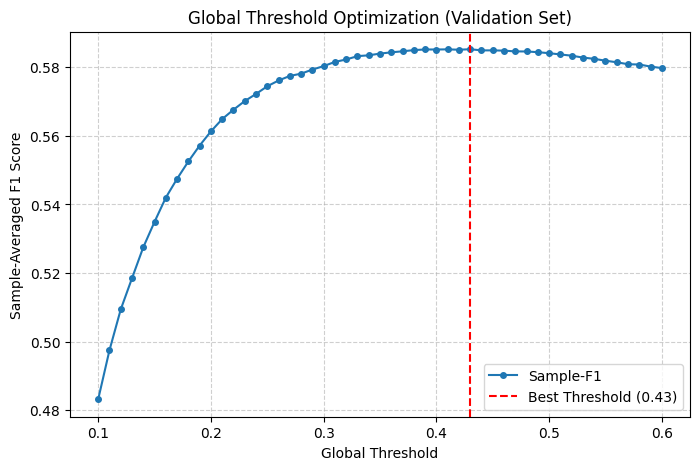

----------------------------------------


Evaluating Batches:  18%|█▊        | 77/438 [00:02<00:11, 32.82it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 31.04it/s]


Optimized Global Threshold: 0.4300
Test F1-Score: 0.587280


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)


model_path = "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed43.pth"
model_efficientnetb0 = ConceptDetectionModel(
    backbone_name="efficientnet_b0",
    num_classes=num_classes,
    pool_type="gem"
).to(device)

state_dict = torch.load(model_path, map_location=device)
model_efficientnetb0.load_state_dict(state_dict)
print(f"Successfully loaded model weights from: {model_path}")

print("\nExtracting probabilities from the validation set...")
val_y_true, val_y_prob = get_probabilities(model_efficientnetb0, val_loader, device=device)

print("\nOptimizing global threshold...")
best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
    val_y_true,
    val_y_prob,
    start=0.1,
    end=0.6,
    steps=51,
    device=device
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', markersize=4, label="Sample-F1")
plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
plt.title("Global Threshold Optimization (Validation Set)")
plt.xlabel("Global Threshold")
plt.ylabel("Sample-Averaged F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("-" * 40)
test_loss, test_f1 = evaluate_with_threshold(model_efficientnetb0, test_loader, criterion, device,best_t)
print(f"Optimized Global Threshold: {best_t:.4f}")
print(f"Test F1-Score: {test_f1:.6f}")

### DenseNet121 Training, Plots and Global Threshold Optimization

In [ ]:
reproducibility(seed=43)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(mlb.classes_)

model_densenet121 = ConceptDetectionModel(
        backbone_name="densenet121",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model_densenet121.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=1
)

print(f"Starting optimized training of DenseNet-121 on {device} with {num_classes} total classes...")
results_densenet121 = train_model(
    model=model_densenet121,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    scheduler=scheduler,
    patience=3,
    device=device
)

print("-" * 40)
test_loss, test_f1 = evaluate(model_densenet121, test_loader, criterion, device)
print(f"Test F1-Score: {test_f1:.6f}")

Random seed set to 43
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 221MB/s]


Starting optimized training of DenseNet-121 on cuda with 2645 total classes...


Evaluating Batches: 100%|██████████| 1203/1203 [00:43<00:00, 27.76it/s]


Epoch 1/30 | Loss (Tr/Val): 0.007339/0.004943 | F1 (Tr/Val): 0.455030/0.557952


...

Epoch 7/30 | Loss (Tr/Val): 0.003636/0.004350 | F1 (Tr/Val): 0.596992/0.575142


Evaluating Batches: 100%|██████████| 1203/1203 [00:43<00:00, 27.52it/s]


Epoch 8/30 | Loss (Tr/Val): 0.003262/0.004343 | F1 (Tr/Val): 0.611842/0.578585
Early stopping triggered at epoch 8 (best val loss: 0.0043)
----------------------------------------
Best Validation F1-Score (Epoch 5): 0.580346
Training Time: 104.51 minutes
----------------------------------------


Evaluating Batches:  18%|█▊        | 77/438 [00:02<00:11, 31.02it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 30.38it/s]


Test F1-Score: 0.585579


Model weights saved to /content/drive/MyDrive/imageclefmed/models/densenet121_1_seed43.pth
Saved training curves to: /content/drive/MyDrive/imageclefmed/plots/densenet121_curves1_seed43.png


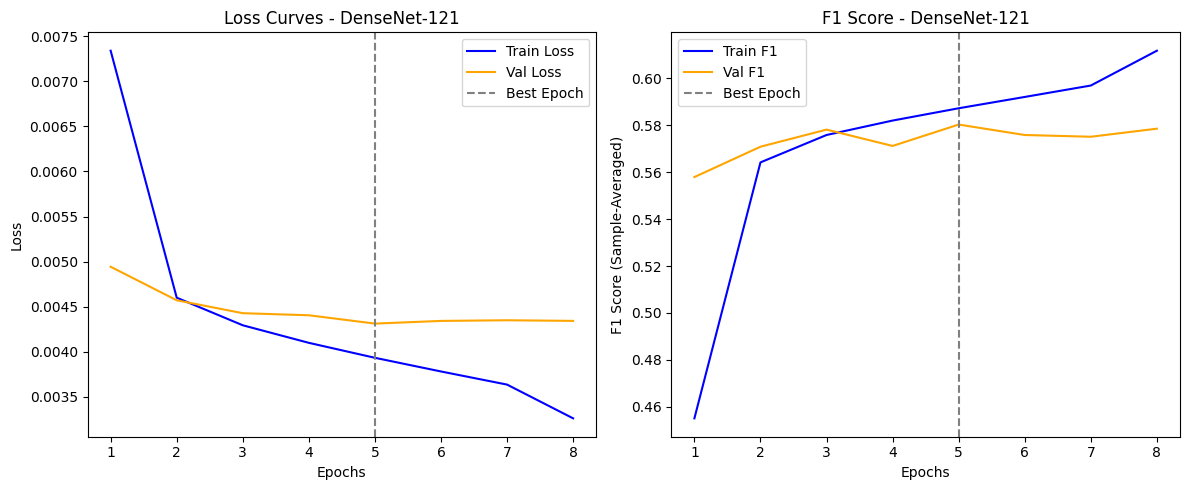

In [ ]:
output_dir_model = "/content/drive/MyDrive/imageclefmed/models"
output_dir_plot = "/content/drive/MyDrive/imageclefmed/plots"

model_save_path = os.path.join(output_dir_model, "densenet121_1_seed43.pth")
torch.save(model_densenet121.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

plot_save_path = os.path.join(output_dir_plot, "densenet121_curves1_seed43.png")
plot_train_curves(results_densenet121, title="DenseNet-121", save_path=plot_save_path)

Successfully loaded model weights from: /content/drive/MyDrive/imageclefmed/models/densenet121_1_seed43.pth

Extracting probabilities from the validation set...


Extracting Probs: 100%|██████████| 1203/1203 [00:42<00:00, 28.31it/s]



Optimizing global threshold...


Testing Global Thresholds: 100%|██████████| 51/51 [00:00<00:00, 153.02it/s]



Optimal Global Threshold: 0.48

Best Validation Sample-F1: 0.580539


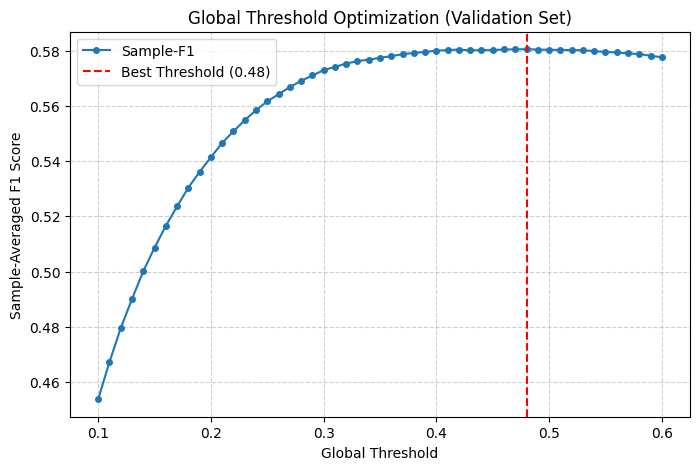

----------------------------------------


Evaluating Batches:  18%|█▊        | 79/438 [00:02<00:11, 31.85it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 31.14it/s]


Optimized Global Threshold: 0.4800
Test F1-Score: 0.585748


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)


model_path = "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed43.pth"
model_densenet121 = ConceptDetectionModel(
    backbone_name="densenet121",
    num_classes=num_classes,
    pool_type="gem"
).to(device)

state_dict = torch.load(model_path, map_location=device)
model_densenet121.load_state_dict(state_dict)
print(f"Successfully loaded model weights from: {model_path}")

print("\nExtracting probabilities from the validation set...")
val_y_true, val_y_prob = get_probabilities(model_densenet121, val_loader, device=device)

print("\nOptimizing global threshold...")
best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
    val_y_true,
    val_y_prob,
    start=0.1,
    end=0.6,
    steps=51,
    device=device
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', markersize=4, label="Sample-F1")
plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
plt.title("Global Threshold Optimization (Validation Set)")
plt.xlabel("Global Threshold")
plt.ylabel("Sample-Averaged F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("-" * 40)
test_loss, test_f1 = evaluate_with_threshold(model_densenet121, test_loader, criterion, device,best_t)
print(f"Optimized Global Threshold: {best_t:.4f}")
print(f"Test F1-Score: {test_f1:.6f}")

### ConvNeXt-Tiny Training, Plots and Global Threshold Optimization

In [ ]:
reproducibility(seed=43)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(mlb.classes_)

model_convnext_tiny = ConceptDetectionModel(
        backbone_name="convnext_tiny",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model_convnext_tiny.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=1
)

print(f"Starting optimized training of ConvNext-Tiny on {device} with {num_classes} total classes...")
results_convnext_tiny = train_model(
    model=model_convnext_tiny,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    scheduler=scheduler,
    patience=3,
    device=device
)

print("-" * 40)
test_loss, test_f1 = evaluate(model_convnext_tiny, test_loader, criterion, device)
print(f"Test F1-Score: {test_f1:.6f}")

Random seed set to 43
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 238MB/s] 


Starting optimized training of ConvNext-Tiny on cuda with 2645 total classes...


Evaluating Batches: 100%|██████████| 1203/1203 [00:45<00:00, 26.62it/s]


Epoch 1/30 | Loss (Tr/Val): 0.006943/0.004671 | F1 (Tr/Val): 0.519996/0.560432


...

Epoch 7/30 | Loss (Tr/Val): 0.002957/0.004243 | F1 (Tr/Val): 0.630600/0.582321


Evaluating Batches: 100%|██████████| 1203/1203 [00:42<00:00, 28.01it/s]


Epoch 8/30 | Loss (Tr/Val): 0.002468/0.004387 | F1 (Tr/Val): 0.662741/0.580853
Early stopping triggered at epoch 8 (best val loss: 0.0041)
----------------------------------------
Best Validation F1-Score (Epoch 5): 0.577019
Training Time: 139.54 minutes
----------------------------------------


Evaluating Batches:  17%|█▋        | 74/438 [00:02<00:12, 30.23it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:17<00:00, 25.63it/s]


Test F1-Score: 0.587830


Model weights saved to /content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth
Saved training curves to: /content/drive/MyDrive/imageclefmed/plots/convnext_tiny_curves1_seed43.png


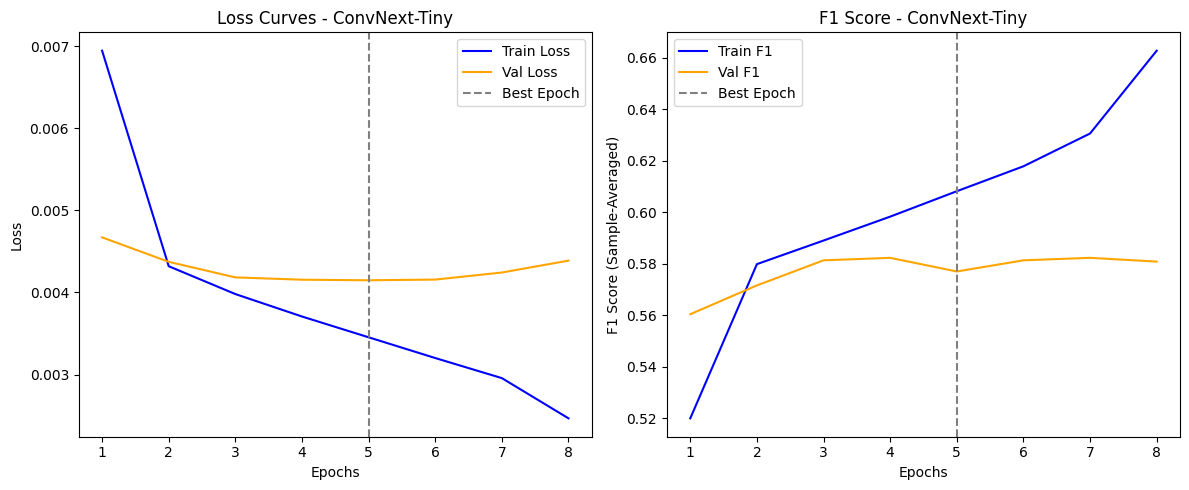

In [ ]:
output_dir_model = "/content/drive/MyDrive/imageclefmed/models"
output_dir_plot = "/content/drive/MyDrive/imageclefmed/plots"

model_save_path = os.path.join(output_dir_model, "convnext_tiny_1_seed43.pth")
torch.save(model_convnext_tiny.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

plot_save_path = os.path.join(output_dir_plot, "convnext_tiny_curves1_seed43.png")
plot_train_curves(results_convnext_tiny, title="ConvNext-Tiny", save_path=plot_save_path)

Successfully loaded model weights from: /content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth

Extracting probabilities from the validation set...


Extracting Probs: 100%|██████████| 1203/1203 [00:42<00:00, 28.05it/s]



Optimizing global threshold...


Testing Global Thresholds: 100%|██████████| 51/51 [00:00<00:00, 153.53it/s]



Optimal Global Threshold: 0.40

Best Validation Sample-F1: 0.579210


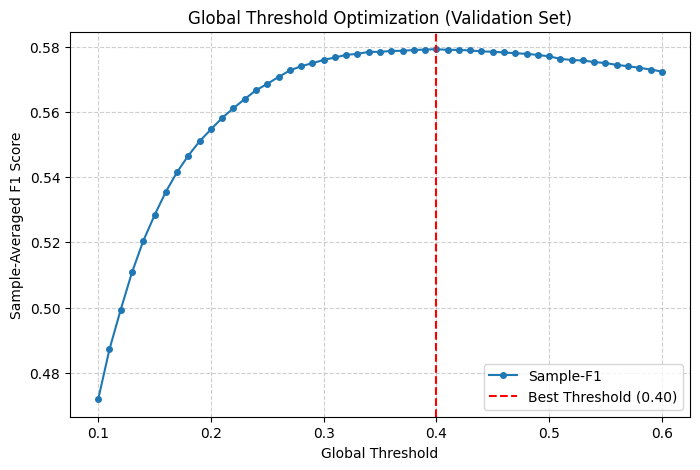

----------------------------------------


Evaluating Batches:  17%|█▋        | 74/438 [00:02<00:11, 30.46it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 29.32it/s]


Optimized Global Threshold: 0.4000
Test F1-Score: 0.589642


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_path = "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth"
model_convnext_tiny = ConceptDetectionModel(
    backbone_name="convnext_tiny",
    num_classes=num_classes,
    pool_type="gem"
).to(device)

state_dict = torch.load(model_path, map_location=device)
model_convnext_tiny.load_state_dict(state_dict)
print(f"Successfully loaded model weights from: {model_path}")

print("\nExtracting probabilities from the validation set...")
val_y_true, val_y_prob = get_probabilities(model_convnext_tiny, val_loader, device=device)

print("\nOptimizing global threshold...")
best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
    val_y_true,
    val_y_prob,
    start=0.1,
    end=0.6,
    steps=51,
    device=device
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', markersize=4, label="Sample-F1")
plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
plt.title("Global Threshold Optimization (Validation Set)")
plt.xlabel("Global Threshold")
plt.ylabel("Sample-Averaged F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("-" * 40)
test_loss, test_f1 = evaluate_with_threshold(model_convnext_tiny, test_loader, criterion, device,best_t)
print(f"Optimized Global Threshold: {best_t:.4f}")
print(f"Test F1-Score: {test_f1:.6f}")

### ResNet50 Training, Plots and Global Threshold Optimization

In [ ]:
reproducibility(seed=43)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(mlb.classes_)

model_resnet50 = ConceptDetectionModel(
        backbone_name="resnet50",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model_resnet50.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=1
)

print(f"Starting optimized training of ResNet-50 on {device} with {num_classes} total classes...")
results_resnet50 = train_model(
    model=model_resnet50,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    scheduler=scheduler,
    patience=3,
    device=device
)

print("-" * 40)
test_loss, test_f1 = evaluate(model_resnet50, test_loader, criterion, device)
print(f"Test F1-Score: {test_f1:.6f}")

Random seed set to 43
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


Starting optimized training of ResNet-50 on cuda with 2645 total classes...


Evaluating Batches: 100%|██████████| 1203/1203 [00:42<00:00, 27.98it/s]


Epoch 1/30 | Loss (Tr/Val): 0.006089/0.004816 | F1 (Tr/Val): 0.491066/0.564455


...

Epoch 8/30 | Loss (Tr/Val): 0.003249/0.004483 | F1 (Tr/Val): 0.616485/0.572202


Evaluating Batches: 100%|██████████| 1203/1203 [00:42<00:00, 28.36it/s]


Epoch 9/30 | Loss (Tr/Val): 0.002788/0.004483 | F1 (Tr/Val): 0.640619/0.574559
Early stopping triggered at epoch 9 (best val loss: 0.0043)
----------------------------------------
Best Validation F1-Score (Epoch 6): 0.575956
Training Time: 100.46 minutes
----------------------------------------


Evaluating Batches:  18%|█▊        | 77/438 [00:02<00:11, 31.73it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 31.06it/s]


Test F1-Score: 0.584945


Model weights saved to /content/drive/MyDrive/imageclefmed/models/resnet50_1_seed43.pth
Saved training curves to: /content/drive/MyDrive/imageclefmed/plots/resnet50_curves1_seed43.png


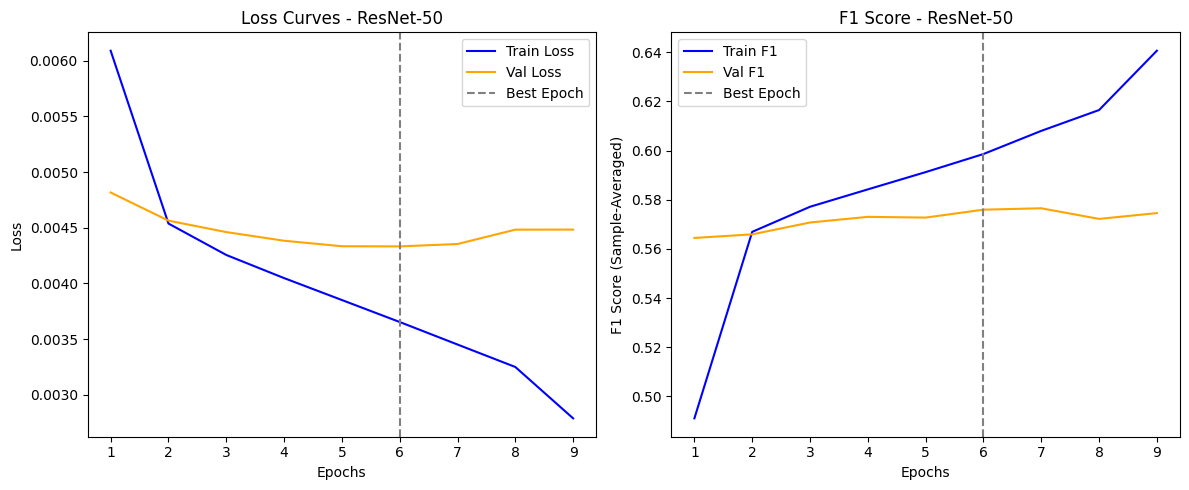

In [ ]:
output_dir_model = "/content/drive/MyDrive/imageclefmed/models"
output_dir_plot = "/content/drive/MyDrive/imageclefmed/plots"

model_save_path = os.path.join(output_dir_model, "resnet50_1_seed43.pth")
torch.save(model_resnet50.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

plot_save_path = os.path.join(output_dir_plot, "resnet50_curves1_seed43.png")
plot_train_curves(results_resnet50, title="ResNet-50", save_path=plot_save_path)

Successfully loaded model weights from: /content/drive/MyDrive/imageclefmed/models/resnet50_1_seed43.pth

Extracting probabilities from the validation set...


Extracting Probs: 100%|██████████| 1203/1203 [00:42<00:00, 28.43it/s]



Optimizing global threshold...


Testing Global Thresholds: 100%|██████████| 51/51 [00:00<00:00, 153.51it/s]



Optimal Global Threshold: 0.47

Best Validation Sample-F1: 0.576164


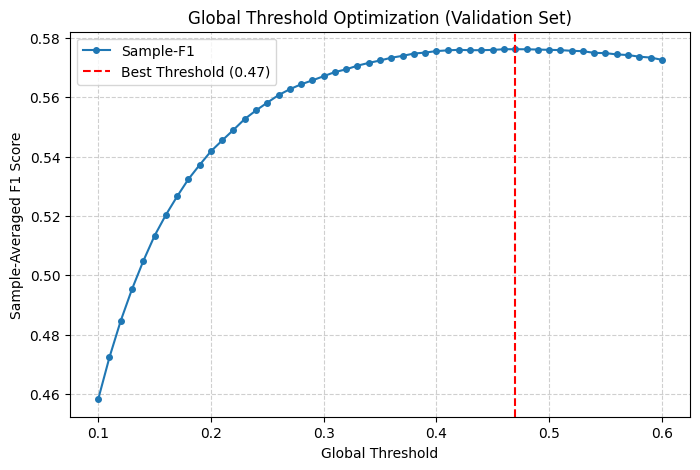

----------------------------------------


Evaluating Batches:  18%|█▊        | 77/438 [00:02<00:10, 32.90it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 30.89it/s]


Optimized Global Threshold: 0.4700
Test F1-Score: 0.585526


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_path = "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed43.pth"
model_resnet50 = ConceptDetectionModel(
    backbone_name="resnet50",
    num_classes=num_classes,
    pool_type="gem"
).to(device)

state_dict = torch.load(model_path, map_location=device)
model_resnet50.load_state_dict(state_dict)
print(f"Successfully loaded model weights from: {model_path}")

print("\nExtracting probabilities from the validation set...")
val_y_true, val_y_prob = get_probabilities(model_resnet50, val_loader, device=device)

print("\nOptimizing global threshold...")
best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
    val_y_true,
    val_y_prob,
    start=0.1,
    end=0.6,
    steps=51,
    device=device
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', markersize=4, label="Sample-F1")
plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
plt.title("Global Threshold Optimization (Validation Set)")
plt.xlabel("Global Threshold")
plt.ylabel("Sample-Averaged F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("-" * 40)
test_loss, test_f1 = evaluate_with_threshold(model_resnet50, test_loader, criterion, device,best_t)
print(f"Optimized Global Threshold: {best_t:.4f}")
print(f"Test F1-Score: {test_f1:.6f}")

### EfficientNetV2S Training, Plots and Global Threshold Optimization

In [ ]:
reproducibility(seed=43)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(mlb.classes_)

model_efficientnet_v2_s = ConceptDetectionModel(
        backbone_name="efficientnet_v2_s",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model_efficientnet_v2_s.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1
)

print(f"Starting optimized training of EfficientNetV2-S on {device} with {num_classes} total classes...")
results_efficientnet_v2_s = train_model(
    model=model_efficientnet_v2_s,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    scheduler=scheduler,
    patience=3,
    device=device
)

print("-" * 40)
test_loss, test_f1 = evaluate(model_efficientnet_v2_s, test_loader, criterion, device)
print(f"Test F1-Score: {test_f1:.6f}")

Random seed set to 43
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 191MB/s]


Starting optimized training of EfficientNetV2-S on cuda with 2645 total classes...


Evaluating Batches: 100%|██████████| 1203/1203 [00:42<00:00, 28.24it/s]


Epoch 1/30 | Loss (Tr/Val): 0.006500/0.004714 | F1 (Tr/Val): 0.482309/0.568511


...

Epoch 7/30 | Loss (Tr/Val): 0.003198/0.004265 | F1 (Tr/Val): 0.614636/0.581328


Evaluating Batches: 100%|██████████| 1203/1203 [00:43<00:00, 27.91it/s]


Epoch 8/30 | Loss (Tr/Val): 0.002818/0.004369 | F1 (Tr/Val): 0.633637/0.582693
Early stopping triggered at epoch 8 (best val loss: 0.0042)
----------------------------------------
Best Validation F1-Score (Epoch 5): 0.582610
Training Time: 110.50 minutes
----------------------------------------


Evaluating Batches:  18%|█▊        | 79/438 [00:02<00:11, 32.63it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 30.53it/s]


Test F1-Score: 0.590050


Model weights saved to /content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed43.pth
Saved training curves to: /content/drive/MyDrive/imageclefmed/plots/efficientnetv2s_curves1_seed43.png


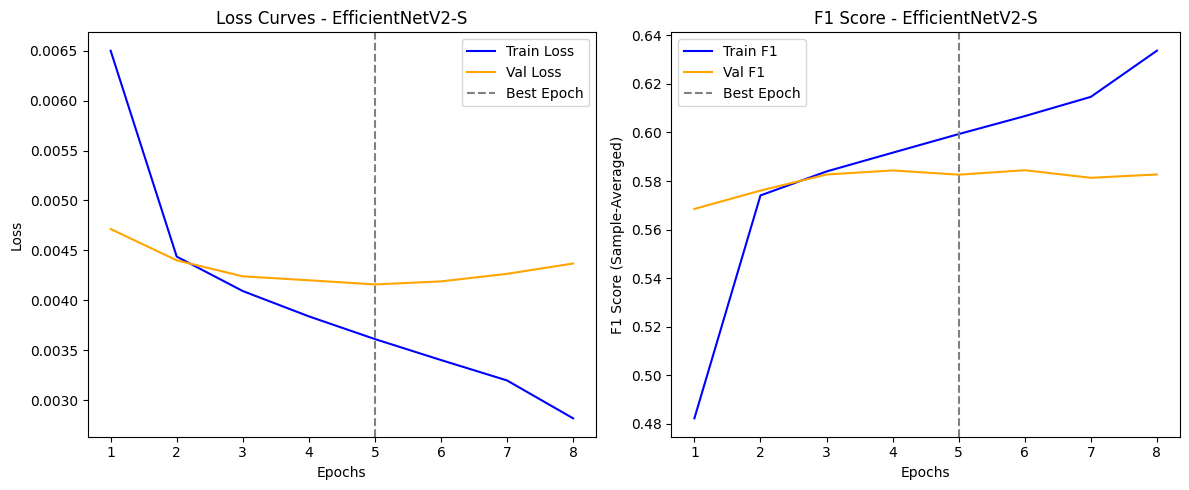

In [ ]:
output_dir_model = "/content/drive/MyDrive/imageclefmed/models"
output_dir_plot = "/content/drive/MyDrive/imageclefmed/plots"

model_save_path = os.path.join(output_dir_model, "efficientnetv2s_1_seed43.pth")
torch.save(model_efficientnet_v2_s.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

plot_save_path = os.path.join(output_dir_plot, "efficientnetv2s_curves1_seed43.png")
plot_train_curves(results_efficientnet_v2_s, title="EfficientNetV2-S", save_path=plot_save_path)

Successfully loaded model weights from: /content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed43.pth

Extracting probabilities from the validation set...


Extracting Probs: 100%|██████████| 1203/1203 [00:42<00:00, 27.98it/s]



Optimizing global threshold...


Testing Global Thresholds: 100%|██████████| 51/51 [00:00<00:00, 153.36it/s]



Optimal Global Threshold: 0.47

Best Validation Sample-F1: 0.583807


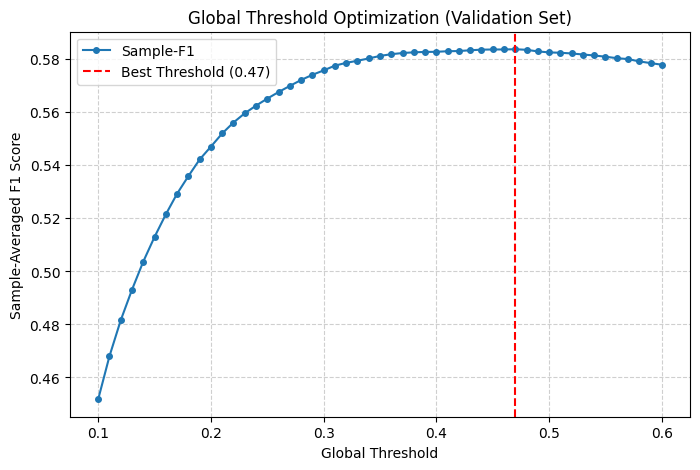

----------------------------------------


Evaluating Batches:  18%|█▊        | 79/438 [00:02<00:10, 32.82it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:14<00:00, 30.66it/s]


Optimized Global Threshold: 0.4700
Test F1-Score: 0.590707


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_path = "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed43.pth"
model_efficientnet_v2_s = ConceptDetectionModel(
    backbone_name="efficientnet_v2_s",
    num_classes=num_classes,
    pool_type="gem"
).to(device)

state_dict = torch.load(model_path, map_location=device)
model_efficientnet_v2_s.load_state_dict(state_dict)
print(f"Successfully loaded model weights from: {model_path}")

print("\nExtracting probabilities from the validation set...")
val_y_true, val_y_prob = get_probabilities(model_efficientnet_v2_s, val_loader, device=device)

print("\nOptimizing global threshold...")
best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
    val_y_true,
    val_y_prob,
    start=0.1,
    end=0.6,
    steps=51,
    device=device
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', markersize=4, label="Sample-F1")
plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
plt.title("Global Threshold Optimization (Validation Set)")
plt.xlabel("Global Threshold")
plt.ylabel("Sample-Averaged F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("-" * 40)
test_loss, test_f1 = evaluate_with_threshold(model_efficientnet_v2_s, test_loader, criterion, device,best_t)
print(f"Optimized Global Threshold: {best_t:.4f}")
print(f"Test F1-Score: {test_f1:.6f}")

### EfficientNetV2M Training, Plots and Global Threshold Optimization

In [ ]:
reproducibility(seed=43)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(mlb.classes_)

model_efficientnet_v2_m = ConceptDetectionModel(
        backbone_name="efficientnet_v2_m",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model_efficientnet_v2_m.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1
)

print(f"Starting optimized training of EfficientNetV2-M on {device} with {num_classes} total classes...")
results_efficientnet_v2_m = train_model(
    model=model_efficientnet_v2_m,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    scheduler=scheduler,
    patience=3,
    device=device
)

print("-" * 40)
test_loss, test_f1 = evaluate(model_efficientnet_v2_m, test_loader, criterion, device)
print(f"Test F1-Score: {test_f1:.6f}")

Random seed set to 43
Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:01<00:00, 208MB/s]


Starting optimized training of EfficientNetV2-M on cuda with 2645 total classes...


Evaluating Batches: 100%|██████████| 1203/1203 [00:48<00:00, 24.89it/s]


Epoch 1/30 | Loss (Tr/Val): 0.006143/0.004636 | F1 (Tr/Val): 0.518005/0.574701


...

Epoch 6/30 | Loss (Tr/Val): 0.003192/0.004203 | F1 (Tr/Val): 0.615449/0.581702


Evaluating Batches: 100%|██████████| 1203/1203 [00:48<00:00, 24.74it/s]


Epoch 7/30 | Loss (Tr/Val): 0.002693/0.004336 | F1 (Tr/Val): 0.643658/0.578178
Early stopping triggered at epoch 7 (best val loss: 0.0041)
----------------------------------------
Best Validation F1-Score (Epoch 4): 0.580989
Training Time: 138.50 minutes
----------------------------------------


Evaluating Batches:  17%|█▋        | 76/438 [00:03<00:13, 25.92it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:17<00:00, 24.86it/s]


Test F1-Score: 0.589525


Model weights saved to /content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth
Saved training curves to: /content/drive/MyDrive/imageclefmed/plots/efficientnetv2m_curves1_seed43.png


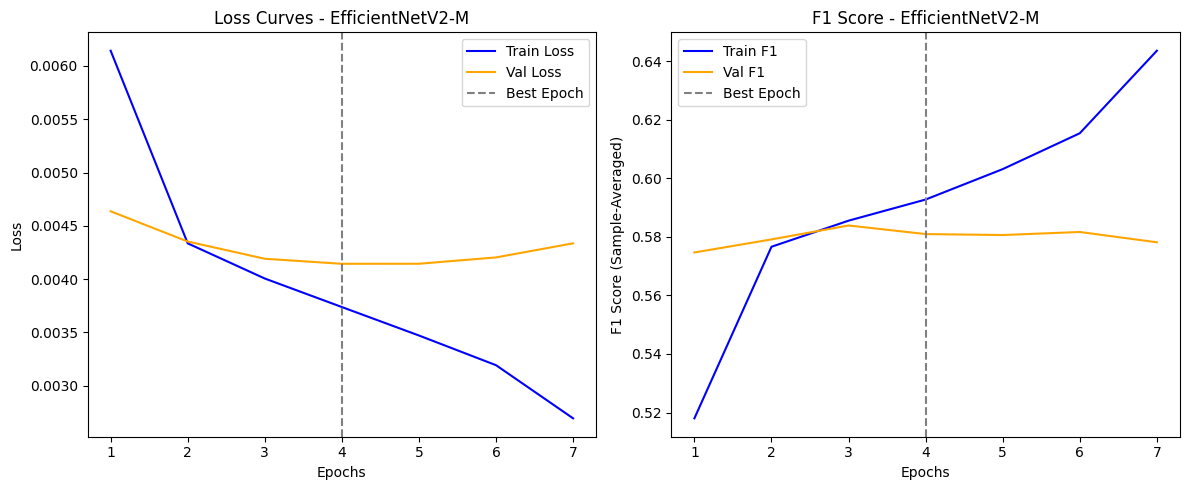

In [ ]:
output_dir_model = "/content/drive/MyDrive/imageclefmed/models"
output_dir_plot = "/content/drive/MyDrive/imageclefmed/plots"

model_save_path = os.path.join(output_dir_model, "efficientnetv2m_1_seed43.pth")
torch.save(model_efficientnet_v2_m.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

plot_save_path = os.path.join(output_dir_plot, "efficientnetv2m_curves1_seed43.png")
plot_train_curves(results_efficientnet_v2_m, title="EfficientNetV2-M", save_path=plot_save_path)

Successfully loaded model weights from: /content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth

Extracting probabilities from the validation set...


Extracting Probs: 100%|██████████| 1203/1203 [00:48<00:00, 24.83it/s]



Optimizing global threshold...


Testing Global Thresholds: 100%|██████████| 51/51 [00:00<00:00, 153.48it/s]



Optimal Global Threshold: 0.38

Best Validation Sample-F1: 0.582756


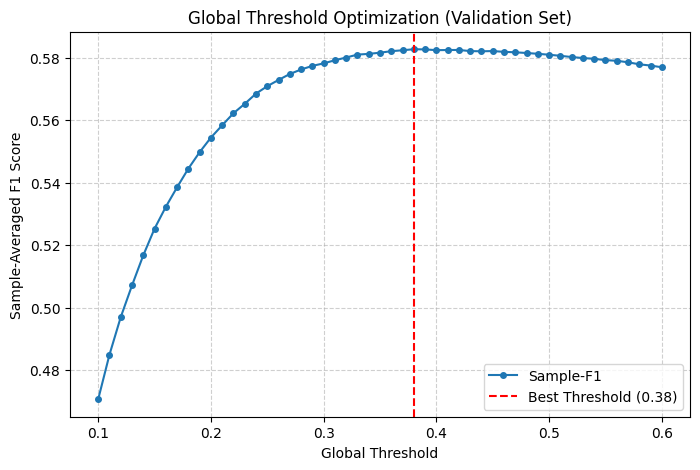

----------------------------------------


Evaluating Batches:  17%|█▋        | 73/438 [00:03<00:14, 24.77it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [00:17<00:00, 24.43it/s]


Optimized Global Threshold: 0.3800
Test F1-Score: 0.590810


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_path = "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth"
model_efficientnet_v2_m = ConceptDetectionModel(
    backbone_name="efficientnet_v2_m",
    num_classes=num_classes,
    pool_type="gem"
).to(device)

state_dict = torch.load(model_path, map_location=device)
model_efficientnet_v2_m.load_state_dict(state_dict)
print(f"Successfully loaded model weights from: {model_path}")

print("\nExtracting probabilities from the validation set...")
val_y_true, val_y_prob = get_probabilities(model_efficientnet_v2_m, val_loader, device=device)

print("\nOptimizing global threshold...")
best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
    val_y_true,
    val_y_prob,
    start=0.1,
    end=0.6,
    steps=51,
    device=device
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', markersize=4, label="Sample-F1")
plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
plt.title("Global Threshold Optimization (Validation Set)")
plt.xlabel("Global Threshold")
plt.ylabel("Sample-Averaged F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("-" * 40)
test_loss, test_f1 = evaluate_with_threshold(model_efficientnet_v2_m, test_loader, criterion, device,best_t)
print(f"Optimized Global Threshold: {best_t:.4f}")
print(f"Test F1-Score: {test_f1:.6f}")

## Monte-Carlo Cross Validation

In [ ]:
class MCCV_ImageCLEFmedDataset(Dataset):
    def __init__(self, df, root_dir, mlb, transform=None):

        self.data_df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.mlb = mlb
        self.image_dir = os.path.join(root_dir, 'images')

        cui_path = os.path.join(root_dir, 'cui_mapping.csv')
        self.cui_mapping = {}
        if os.path.exists(cui_path):
            cui_df = pd.read_csv(cui_path)
            self.cui_mapping = dict(zip(cui_df['CUI'], cui_df['Canonical name']))

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        row = self.data_df.iloc[idx]
        img_id = row['ID']

        cui_string = row['CUIs']
        cuis = str(cui_string).split(';') if pd.notna(cui_string) else []

        img_name = os.path.join(self.image_dir, f"{img_id}.jpg")
        image = Image.open(img_name).convert('RGB')

        if self.transform:
            image = self.transform(image)

        binary_labels = self.mlb.transform([cuis])[0]
        label_tensor = torch.tensor(binary_labels, dtype=torch.float32)

        return {
            'id': img_id,
            'image': image,
            'labels': label_tensor
        }

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_path = '/content/dev_concept_with_mapping/dev_concept'
all_concepts_df = pd.read_csv(f'{dataset_path}/concepts.csv')

test_concepts_df = pd.read_csv(f'{dataset_path}/test_concepts.csv')
test_ids = set(test_concepts_df['ID'].tolist())
print(f"Test samples held out: {len(test_ids)}")

train_concepts_df = all_concepts_df[
    all_concepts_df['ID'].str.contains('train', case=False, na=False) &
    ~all_concepts_df['ID'].isin(test_ids)
]

valid_concepts_df = all_concepts_df[
    all_concepts_df['ID'].str.contains('valid', case=False, na=False) &
    ~all_concepts_df['ID'].isin(test_ids)
]

merged_df = pd.concat([train_concepts_df, valid_concepts_df], ignore_index=True)
print(f"Total Merged Train+Val Samples: {len(merged_df)}")

all_cuis = merged_df['CUIs'].dropna().apply(lambda x: str(x).split(';')).tolist()
mlb = MultiLabelBinarizer()

Y_binary = mlb.fit_transform(all_cuis)
num_classes = len(mlb.classes_)

msss = MultilabelStratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

save_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
os.makedirs(save_dir, exist_ok=True)

print("\n" + "="*50)
print(f"Starting 5-Split MCCV Training with Iterative Stratification...")
print("="*50)

test_dataset = MCCV_ImageCLEFmedDataset(test_concepts_df, dataset_path, mlb, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

mccv_results = {}
mccv_thresholds = {}

for split_idx, (train_idx, val_idx) in enumerate(msss.split(merged_df, Y_binary), 1):
    print(f"\n--- [Split {split_idx}/5] Preparing Data ---")

    train_df_split = merged_df.iloc[train_idx]
    val_df_split = merged_df.iloc[val_idx]

    print(f"Split Train: {len(train_df_split)} | Split Val: {len(val_df_split)}")

    split_train_dataset = MCCV_ImageCLEFmedDataset(train_df_split, dataset_path, mlb, transform)
    split_val_dataset   = MCCV_ImageCLEFmedDataset(val_df_split, dataset_path, mlb, transform)

    split_train_loader = DataLoader(split_train_dataset, batch_size=16, shuffle=True, num_workers=4)
    split_val_loader   = DataLoader(split_val_dataset, batch_size=16, shuffle=False, num_workers=4)

    reproducibility(seed=42)

    model = ConceptDetectionModel(
        backbone_name="efficientnet_v2_s",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1
    )

    print(f"Training Model for Split {split_idx}...")
    train_model(
        model=model,
        train_loader=split_train_loader,
        val_loader=split_val_loader,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=30,
        scheduler=scheduler,
        patience=3,
        device=device
    )

    print(f"\nExtracting probabilities from Split {split_idx} Validation Set...")
    val_y_true, val_y_prob = get_probabilities(model, split_val_loader, device=device)

    print(f"Optimizing global threshold for Split {split_idx}...")
    best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
        val_y_true,
        val_y_prob,
        start=0.1,
        end=0.6,
        steps=51,
        device=device
    )

    print(f"-> Optimized Global Threshold: {best_t:.4f} (Val F1: {best_f1:.6f})")
    mccv_thresholds[f"split_{split_idx}"] = best_t

    test_loss, test_f1 = evaluate_with_threshold(model, test_loader, criterion, device, best_t)
    print(f"-> Test F1-Score for Split {split_idx} (w/ t={best_t:.4f}): {test_f1:.6f}")

    mccv_results[f"split_{split_idx}"] = test_f1

    save_path = os.path.join(save_dir, f"efficientnet_v2_s_mccv_split{split_idx}.pth")
    torch.save(model.state_dict(), save_path)

print("\n" + "="*50)
print("Iterative Stratification MCCV Training Complete!")
print("="*50)

thresholds_path = os.path.join(save_dir, "efficientnet_v2_s_mccv_thresholds.json")
with open(thresholds_path, 'w') as f:
    json.dump(mccv_thresholds, f, indent=4)
print(f"All optimized thresholds saved to: {thresholds_path}")

for split_name, f1 in mccv_results.items():
    t_val = mccv_thresholds[split_name]
    print(f"EfficientNetV2S ({split_name}): Test F1 = {f1:.6f} | Threshold = {t_val:.4f}")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_path = '/content/dev_concept_with_mapping/dev_concept'
all_concepts_df = pd.read_csv(f'{dataset_path}/concepts.csv')

test_concepts_df = pd.read_csv(f'{dataset_path}/test_concepts.csv')
test_ids = set(test_concepts_df['ID'].tolist())
print(f"Test samples held out: {len(test_ids)}")

train_concepts_df = all_concepts_df[
    all_concepts_df['ID'].str.contains('train', case=False, na=False) &
    ~all_concepts_df['ID'].isin(test_ids)
]

valid_concepts_df = all_concepts_df[
    all_concepts_df['ID'].str.contains('valid', case=False, na=False) &
    ~all_concepts_df['ID'].isin(test_ids)
]

merged_df = pd.concat([train_concepts_df, valid_concepts_df], ignore_index=True)
print(f"Total Merged Train+Val Samples: {len(merged_df)}")

all_cuis = merged_df['CUIs'].dropna().apply(lambda x: str(x).split(';')).tolist()
mlb = MultiLabelBinarizer()

Y_binary = mlb.fit_transform(all_cuis)
num_classes = len(mlb.classes_)

msss = MultilabelStratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

save_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
os.makedirs(save_dir, exist_ok=True)

print("\n" + "="*50)
print(f"Starting 5-Split MCCV Training with Iterative Stratification...")
print("="*50)

test_dataset = MCCV_ImageCLEFmedDataset(test_concepts_df, dataset_path, mlb, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

mccv_results = {}
mccv_thresholds = {}

for split_idx, (train_idx, val_idx) in enumerate(msss.split(merged_df, Y_binary), 1):

    if split_idx <= 3:
        print(f"Skipping Split {split_idx}/5 (Already trained and saved)...")
        continue

    print(f"\n--- [Split {split_idx}/5] Preparing Data ---")

    train_df_split = merged_df.iloc[train_idx]
    val_df_split = merged_df.iloc[val_idx]

    print(f"Split Train: {len(train_df_split)} | Split Val: {len(val_df_split)}")

    split_train_dataset = MCCV_ImageCLEFmedDataset(train_df_split, dataset_path, mlb, transform)
    split_val_dataset   = MCCV_ImageCLEFmedDataset(val_df_split, dataset_path, mlb, transform)

    split_train_loader = DataLoader(split_train_dataset, batch_size=16, shuffle=True, num_workers=4)
    split_val_loader   = DataLoader(split_val_dataset, batch_size=16, shuffle=False, num_workers=4)

    reproducibility(seed=42)

    model = ConceptDetectionModel(
        backbone_name="efficientnet_v2_s",
        num_classes=num_classes,
        pool_type="gem"
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1
    )

    print(f"Training Model for Split {split_idx}...")
    train_model(
        model=model,
        train_loader=split_train_loader,
        val_loader=split_val_loader,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=30,
        scheduler=scheduler,
        patience=3,
        device=device
    )

    print(f"\nExtracting probabilities from Split {split_idx} Validation Set...")
    val_y_true, val_y_prob = get_probabilities(model, split_val_loader, device=device)

    print(f"Optimizing global threshold for Split {split_idx}...")
    best_t, best_f1, thresholds, f1_scores = find_best_global_threshold(
        val_y_true,
        val_y_prob,
        start=0.1,
        end=0.6,
        steps=51,
        device=device
    )

    print(f"-> Optimized Global Threshold: {best_t:.4f} (Val F1: {best_f1:.6f})")
    mccv_thresholds[f"split_{split_idx}"] = best_t

    test_loss, test_f1 = evaluate_with_threshold(model, test_loader, criterion, device, best_t)
    print(f"-> Test F1-Score for Split {split_idx} (w/ t={best_t:.4f}): {test_f1:.6f}")

    mccv_results[f"split_{split_idx}"] = test_f1

    save_path = os.path.join(save_dir, f"efficientnet_v2_s_mccv_split{split_idx}.pth")
    torch.save(model.state_dict(), save_path)

print("\n" + "="*50)
print("Iterative Stratification MCCV Training Complete!")
print("="*50)

thresholds_path = os.path.join(save_dir, "efficientnet_v2_s_mccv_thresholds.json")
with open(thresholds_path, 'w') as f:
    json.dump(mccv_thresholds, f, indent=4)
print(f"All optimized thresholds saved to: {thresholds_path}")

for split_name, f1 in mccv_results.items():
    t_val = mccv_thresholds[split_name]
    print(f"EfficientNetV2S ({split_name}): Test F1 = {f1:.6f} | Threshold = {t_val:.4f}")

## Conformal Count Regressor

In [ ]:
class ConceptCountRegressor(nn.Module):
    def __init__(self, backbone_name, dropout=0.2, pool_type="gem", gem_p=3.0):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone = get_backbone(backbone_name)
        num_features = FEATURE_DIMS[backbone_name]

        for param in self.backbone.parameters():
            param.requires_grad = False

        if pool_type == "gem":
            self.pool = GeM(p=gem_p, p_trainable=True)
        else:
            self.pool = nn.AdaptiveAvgPool2d(1)

        self.flatten = nn.Flatten()

        self.regressor = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.flatten(x)
        return self.regressor(x).squeeze(-1)

In [ ]:
def train_count_regressor(model, train_loader, val_loader, epochs=15, patience=3, device="cuda"):
    model.to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            x = batch['image'].to(device)
            y_true_count = batch['labels'].sum(dim=1).float().to(device)

            optimizer.zero_grad()
            y_pred_count = model(x)

            loss = criterion(y_pred_count, y_true_count)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                x = batch['image'].to(device)
                y_true_count = batch['labels'].sum(dim=1).float().to(device)

                y_pred_count = model(x)
                loss = criterion(y_pred_count, y_true_count)

                val_loss += loss.item() * x.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)

        print(f"Epoch {epoch+1} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f" -> Validation loss improved! Saving weights.")
        else:
            epochs_no_improve += 1
            print(f" -> No improvement for {epochs_no_improve} epoch(s).")

            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}!")
                break

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f"\nRestored best model weights with Val MSE: {best_val_loss:.4f}")

    return model

In [ ]:
reproducibility()
print("Training the Cardinality Regressor with Early Stopping...")
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_b0").to(device)
regressor_model = train_count_regressor(
    model=regressor_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    patience=3,
    device=device
)

regressor_save_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_2.pth"

torch.save(regressor_model.state_dict(), regressor_save_path)

print(f"Regressor model successfully saved to: {regressor_save_path}")

Random seed set to 42
Training the Cardinality Regressor with Early Stopping...


Epoch 1/15 [Val]: 100%|██████████| 1203/1203 [00:42<00:00, 28.47it/s]


Epoch 1 | Train MSE: 3.1224 | Val MSE: 3.4071
 -> Validation loss improved! Saving weights.


Epoch 2/15 [Val]: 100%|██████████| 1203/1203 [00:41<00:00, 28.71it/s]


Epoch 2 | Train MSE: 2.9460 | Val MSE: 3.3346
 -> Validation loss improved! Saving weights.


...

Epoch 8 | Train MSE: 2.6826 | Val MSE: 3.1411
 -> No improvement for 1 epoch(s).


Epoch 9/15 [Val]: 100%|██████████| 1203/1203 [00:41<00:00, 28.87it/s]


Epoch 9 | Train MSE: 2.6807 | Val MSE: 3.1443
 -> No improvement for 2 epoch(s).


Epoch 10/15 [Val]: 100%|██████████| 1203/1203 [00:42<00:00, 28.54it/s]


Epoch 10 | Train MSE: 2.6835 | Val MSE: 3.1420
 -> No improvement for 3 epoch(s).

Early stopping triggered at epoch 10!

Restored best model weights with Val MSE: 3.1379
Regressor model successfully saved to: /content/drive/MyDrive/imageclefmed/models/count_regressor_2.pth


In [ ]:
def calibrate_conformal_regressor(model, val_loader, alpha=0.1, device="cuda"):
    model.eval()
    residuals = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Calibrating Conformal Intervals"):
            x = batch['image'].to(device)
            y_true_count = batch['labels'].sum(dim=1).float().to(device)

            y_pred_count = model(x)

            res = torch.abs(y_true_count - y_pred_count)
            residuals.extend(res.cpu().tolist())

    residuals = np.array(residuals)
    n = len(residuals)

    q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    q_val = np.quantile(residuals, q_level)

    print(f"\nConformal Calibration Complete.")
    print(f"Target Confidence: {100 * (1 - alpha)}%")
    print(f"Calculated Quantile (q): {q_val:.4f} concepts")

    return q_val

In [ ]:
reproducibility()
q_val = calibrate_conformal_regressor(regressor_model, val_loader, alpha=0.1, device=device)

Random seed set to 42


Calibrating Conformal Intervals: 100%|██████████| 1203/1203 [00:42<00:00, 28.57it/s]


Conformal Calibration Complete.
Target Confidence: 90.0%
Calculated Quantile (q): 2.4246 concepts


In [ ]:
def apply_bidirectional_conformal(base_preds, avg_probs, lower_bounds, upper_bounds):
    final_preds = base_preds.copy()
    current_counts = np.sum(final_preds, axis=1)
    C = avg_probs.shape[1]

    needs_rescue = current_counts < lower_bounds
    if np.any(needs_rescue):
        rescue_idx = np.where(needs_rescue)[0]
        missing = lower_bounds[rescue_idx] - current_counts[rescue_idx]

        subset_base = final_preds[rescue_idx]
        subset_probs = avg_probs[rescue_idx]

        masked_probs = np.where(subset_base > 0, -np.inf, subset_probs)
        sort_idx = np.argsort(masked_probs, axis=1)[:, ::-1]

        ranks = np.empty_like(sort_idx)
        np.put_along_axis(ranks, sort_idx, np.arange(C).reshape(1, -1), axis=1)

        rescue_mask = ranks < missing[:, None]
        final_preds[rescue_idx] = subset_base | rescue_mask.astype(base_preds.dtype)

    current_counts = np.sum(final_preds, axis=1)

    needs_prune = current_counts > upper_bounds
    if np.any(needs_prune):
        prune_idx = np.where(needs_prune)[0]
        surplus = current_counts[prune_idx] - upper_bounds[prune_idx]

        subset_base = final_preds[prune_idx]
        subset_probs = avg_probs[prune_idx]

        masked_probs_prune = np.where(subset_base == 0, np.inf, subset_probs)
        sort_idx_prune = np.argsort(masked_probs_prune, axis=1)

        ranks_prune = np.empty_like(sort_idx_prune)
        np.put_along_axis(ranks_prune, sort_idx_prune, np.arange(C).reshape(1, -1), axis=1)

        prune_mask = ranks_prune < surplus[:, None]

        final_preds[prune_idx] = subset_base & ~prune_mask.astype(base_preds.dtype)

    return final_preds

## Grid Search to Determine the Best Model Combinations for the Ensemble

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_b0_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "resnet50_seed40": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "efficientnet_v2_s_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed43.pth",
    "efficientnet_b0_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed43.pth",
    "densenet121_seed43": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
    "resnet50_seed43": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_b0_seed40": 0.42,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "resnet50_seed40": 0.42,
    "efficientnet_v2_m_seed43": 0.38,
    "efficientnet_v2_s_seed43": 0.47,
    "efficientnet_b0_seed43": 0.43,
    "densenet121_seed43": 0.48,
    "convnext_tiny_seed43": 0.40,
    "resnet50_seed43": 0.47,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

print("Phase 1: Running inference on the set...")
all_targets = []
all_lower_bounds = []
all_upper_bounds = []

model_names = list(model_configs.keys())
all_probs_list = [[] for _ in range(M)]
all_binary_preds_list = [[] for _ in range(M)]

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Extracting Features"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)
        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))

            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

        for idx, backbone_name in enumerate(model_names):
            model = ensemble_models[backbone_name]
            logits = model(x)
            probs = torch.sigmoid(logits)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_probs_list[idx].append(probs.cpu().numpy())
            all_binary_preds_list[idx].append(preds.cpu().numpy())

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

all_probs = np.array([np.vstack(p) for p in all_probs_list])
all_binary_preds = np.array([np.vstack(p) for p in all_binary_preds_list])

print(f"Extraction complete! Array shape: {all_binary_preds.shape}")

np.savez_compressed(
    "/content/drive/MyDrive/imageclefmed/ensemble_extracted_features.npz",
    targets=all_targets,
    lower_bounds=all_lower_bounds,
    upper_bounds=all_upper_bounds,
    probs=all_probs,
    binary_preds=all_binary_preds
)
print("Saved all extracted features to disk!")

In [ ]:
print("Loading extracted features...")
data = np.load("/content/drive/MyDrive/imageclefmed/ensemble_extracted_features.npz")

all_targets = data['targets']
all_lower_bounds = data['lower_bounds']
all_upper_bounds = data['upper_bounds']
all_probs = data['probs']
all_binary_preds = data['binary_preds']

M = all_probs.shape[0]
model_names = [
    "efficientnet_v2_m", "efficientnet_v2_s", "convnext_tiny", "densenet121",
    "efficientnet_b0", "resnet50", "efficientnet_v2_m_seed41", "efficientnet_v2_s_seed41",
    "convnext_tiny_seed41", "densenet121_seed41", "efficientnet_b0_seed41", "resnet50_seed41",
    "convnext_tiny_seed40", "densenet121_seed40", "efficientnet_b0_seed40",
    "efficientnet_v2_m_seed40", "efficientnet_v2_s_seed40", "resnet50_seed40",
    "convnext_tiny_seed43", "densenet121_seed43", "efficientnet_b0_seed43",
    "efficientnet_v2_m_seed43", "efficientnet_v2_s_seed43", "resnet50_seed43",
]

best_f1 = 0.0
best_combination = None
best_L = 0

print(f"\nStarting Grid Search on CPU... (Evaluating up to {M} models)")

for k in range(1, M + 1):
    combos = itertools.combinations(range(M), k)

    total_combos = math.comb(M, k)

    for subset_indices in tqdm(combos, total=total_combos, desc=f"K={k} Search", leave=False):
        subset_indices = list(subset_indices)

        subset_binary = all_binary_preds[subset_indices]
        subset_probs = all_probs[subset_indices]

        V = np.sum(subset_binary, axis=0)
        subset_avg_probs = np.mean(subset_probs, axis=0)

        for L in range(1, k + 1):
            base_preds = (V >= L).astype(int)

            final_preds = apply_bidirectional_conformal(
                base_preds,
                subset_avg_probs,
                all_lower_bounds,
                all_upper_bounds
            )

            current_f1 = f1_score(all_targets, final_preds, average='samples', zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_combination = [model_names[i] for i in subset_indices]
                best_L = L

print("\n" + "="*50)
print("BEST ENSEMBLE COMBINATION FOUND")
print("="*50)
print(f"Optimal Ensemble Size : {len(best_combination)} Models")
print(f"Optimal L-Threshold   : {best_L}")
print(f"Highest F1 Score      : {best_f1:.6f}")
print("\nModels included in this winning combination:")
for model_name in best_combination:
    print(f" - {model_name}")
print("="*50)

## Mondrian Conformal

In [ ]:
def calibrate_mondrian_conformal_regressor(model, val_loader, bins=[3, 6], alpha=0.1, device="cuda"):
    model.eval()
    all_residuals = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Calibrating Mondrian Intervals"):
            x = batch['image'].to(device)
            y_true_count = batch['labels'].sum(dim=1).float().to(device)

            y_pred_count = model(x)
            res = torch.abs(y_true_count - y_pred_count)

            all_residuals.extend(res.cpu().tolist())
            all_preds.extend(y_pred_count.cpu().tolist())

    all_residuals = np.array(all_residuals)
    all_preds = np.array(all_preds)

    n_global = len(all_residuals)
    q_level_global = min(1.0, np.ceil((n_global + 1) * (1 - alpha)) / n_global)
    fallback_q = np.quantile(all_residuals, q_level_global)

    bin_assignments = np.digitize(all_preds, bins)
    unique_bins = np.unique(bin_assignments)

    q_vals_dict = {}

    print(f"\n--- Mondrian Conformal Calibration Complete ---")
    print(f"Target Confidence : {100 * (1 - alpha):.1f}%")

    for b in range(len(bins) + 1):
        mask = (bin_assignments == b)
        bin_residuals = all_residuals[mask]
        n = len(bin_residuals)

        lower = 0 if b == 0 else bins[b-1]
        upper = "inf" if b == len(bins) else bins[b]
        bin_name = f"Preds ({lower} to {upper})"

        if n < 10:
            print(f"Bin {b} [{bin_name:^15}]: N={n:<4d} | WARNING: Too few samples. Will use fallback.")
            q_vals_dict[b] = fallback_q
            continue

        q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
        q_val = np.quantile(bin_residuals, q_level)

        q_vals_dict[b] = q_val
        print(f"Bin {b} [{bin_name:^15}]: N={n:<4d} | q_val = {q_val:.4f} concepts")

    return q_vals_dict, bins, fallback_q

In [ ]:
print("Calculating optimal dynamic bins...")
regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()
all_val_preds = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Scanning Predictions"):
        x = batch['image'].to(device)
        preds = regressor_model(x)
        all_val_preds.extend(preds.cpu().numpy())

optimal_bins = np.percentile(all_val_preds, [25, 50, 75])

optimal_bins = [round(b, 2) for b in optimal_bins]

print(f"\n=> The mathematically optimal bins are: {optimal_bins}")

Calculating optimal dynamic bins...


Scanning Predictions: 100%|██████████| 1203/1203 [00:48<00:00, 24.89it/s]


=> The mathematically optimal bins are: [np.float64(3.14), np.float64(3.2), np.float64(3.3)]


In [ ]:
regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

mondrian_q_vals, m_bins, fallback_q = calibrate_mondrian_conformal_regressor(
    regressor_model, val_loader, bins=optimal_bins, alpha=0.1
)

Calibrating Mondrian Intervals: 100%|██████████| 1203/1203 [00:48<00:00, 24.67it/s]


--- Mondrian Conformal Calibration Complete ---
Target Confidence : 90.0%
Bin 0 [Preds (0 to 3.14)]: N=5066 | q_val = 2.1216 concepts
Bin 1 [Preds (3.14 to 3.2)]: N=4337 | q_val = 2.1935 concepts
Bin 2 [Preds (3.2 to 3.3)]: N=5074 | q_val = 2.2980 concepts
Bin 3 [Preds (3.3 to inf)]: N=4763 | q_val = 2.5180 concepts


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

all_targets = []
all_binary_preds = {name: [] for name in model_configs.keys()}
all_avg_probs = []
all_lower_bounds = []
all_upper_bounds = []

all_probs_per_model = {name: [] for name in model_configs.keys()}

print("Running inference on the set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)
        np_pred_counts_batch = pred_counts.cpu().numpy()

        batch_probs = []

        for backbone_name, model in ensemble_models.items():
            logits = model(x)
            probs = torch.sigmoid(logits)
            batch_probs.append(probs)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()
            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        avg_probs = torch.stack(batch_probs).mean(dim=0)
        all_avg_probs.append(avg_probs.cpu().numpy())

        batch_bins = np.digitize(np_pred_counts_batch, m_bins)

        for j in range(x.size(0)):
            pred_val = np_pred_counts_batch[j]
            b_idx = batch_bins[j]

            dynamic_q = mondrian_q_vals.get(b_idx, fallback_q)

            lb = max(1, int(np.floor(pred_val - dynamic_q)))
            ub = int(np.ceil(pred_val + dynamic_q))

            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []

print("Applying conformal adjustments to individual models...")
for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds,
        model_probs,
        all_lower_bounds,
        all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)

V_conf = np.sum(stacked_conf_preds, axis=-1)

for i in range(1, M):
    L_dual = i

    final_dual_preds_conf = (V_conf >= L_dual).astype(int)

    f1_dual_final_conf = official_clef_f1(all_targets, final_dual_preds_conf, mlb)

    print(f"\n--- Strategy: Conformal-First -> Dual Threshold (L={L_dual}) ---")
    print(f"Final F1 Score (Conformal -> Ensemble): {f1_dual_final_conf:.6f}")

Successfully loaded 18 diverse models for ensembling.
Running inference on the set...


Evaluating Batches:  17%|█▋        | 73/438 [00:33<02:45,  2.20it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [03:19<00:00,  2.20it/s]


Applying conformal adjustments to individual models...

--- Strategy: Conformal-First -> Dual Threshold (L=1) ---
Final F1 Score (Conformal -> Ensemble): 0.562177

--- Strategy: Conformal-First -> Dual Threshold (L=2) ---
Final F1 Score (Conformal -> Ensemble): 0.588852

--- Strategy: Conformal-First -> Dual Threshold (L=3) ---
Final F1 Score (Conformal -> Ensemble): 0.596920

--- Strategy: Conformal-First -> Dual Threshold (L=4) ---
Final F1 Score (Conformal -> Ensemble): 0.599167

--- Strategy: Conformal-First -> Dual Threshold (L=5) ---
Final F1 Score (Conformal -> Ensemble): 0.600717

--- Strategy: Conformal-First -> Dual Threshold (L=6) ---
Final F1 Score (Conformal -> Ensemble): 0.600610

--- Strategy: Conformal-First -> Dual Threshold (L=7) ---
Final F1 Score (Conformal -> Ensemble): 0.600219

--- Strategy: Conformal-First -> Dual Threshold (L=8) ---
Final F1 Score (Conformal -> Ensemble): 0.598981

--- Strategy: Conformal-First -> Dual Threshold (L=9) ---
Final F1 Score (Confor

## Ensemble with Dual Thresholding Aggregation and Apply Bidirectional Conformal Rescue

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M_standard = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46, "efficientnet_v2_s": 0.42, "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41, "resnet50": 0.47, "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46, "efficientnet_v2_s_seed41": 0.45, "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40, "resnet50_seed41": 0.40, "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41, "densenet121_seed40": 0.46, "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39, "efficientnet_v2_m_seed43": 0.38, "convnext_tiny_seed43": 0.40,
}

ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(backbone_name=clean_backbone, num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device).eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M_standard} standard models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_avg_probs = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds_standard = {name: [] for name in model_configs.keys()}

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)

        batch_all_probs = []

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            batch_all_probs.append(probs)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()
            all_binary_preds_standard[backbone_name].append(preds.cpu().numpy())

        avg_probs = torch.stack(batch_all_probs).mean(dim=0)
        all_avg_probs.append(avg_probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_avg_probs = np.vstack(all_avg_probs)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

print("Stacking final ensemble voting pool...")
standard_preds_list = [np.vstack(preds) for preds in all_binary_preds_standard.values()]

final_voting_pool = standard_preds_list
stacked_final_preds = np.stack(final_voting_pool, axis=-1)

V = np.sum(stacked_final_preds, axis=-1)
total_voters = len(final_voting_pool)

print("\n" + "="*50)
print("Evaluating Post-Ensemble Conformal Strategies")
print("="*50)

for L_dual in range(1, total_voters + 1):
    base_dual_preds = (V >= L_dual).astype(int)

    final_dual_preds = apply_bidirectional_conformal(
        base_dual_preds,
        all_avg_probs,
        all_lower_bounds,
        all_upper_bounds
    )

    f1_dual_base = official_clef_f1(all_targets, base_dual_preds, mlb)
    f1_dual_final = official_clef_f1(all_targets, final_dual_preds, mlb)

    print(f"\n--- Strategy: Dual Threshold (L={L_dual}) ---")
    print(f"Base F1 Score (No Regressor) : {f1_dual_base:.6f}")
    print(f"Final F1 Score (w/ Regressor): {f1_dual_final:.6f}")

print(f"\n--- Baselines ---")
print(f"Pure Union F1: {official_clef_f1(all_targets, (V >= 1).astype(int), mlb):.4f}")
print(f"Pure Intersection F1: {official_clef_f1(all_targets, (V == total_voters).astype(int), mlb):.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:00<00:00, 243MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 237MB/s]


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


...

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Successfully loaded 18 standard models for ensembling.
Running inference on the test set...


Evaluating Batches:  17%|█▋        | 73/438 [00:36<02:39,  2.29it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [03:18<00:00,  2.20it/s]


Stacking final ensemble voting pool...

Evaluating Post-Ensemble Conformal Strategies

--- Strategy: Dual Threshold (L=1) ---
Base F1 Score (No Regressor) : 0.562580
Final F1 Score (w/ Regressor): 0.563469

--- Strategy: Dual Threshold (L=2) ---
Base F1 Score (No Regressor) : 0.589008
Final F1 Score (w/ Regressor): 0.589029

--- Strategy: Dual Threshold (L=3) ---
Base F1 Score (No Regressor) : 0.596899
Final F1 Score (w/ Regressor): 0.596942

--- Strategy: Dual Threshold (L=4) ---
Base F1 Score (No Regressor) : 0.599073
Final F1 Score (w/ Regressor): 0.599089

--- Strategy: Dual Threshold (L=5) ---
Base F1 Score (No Regressor) : 0.600706
Final F1 Score (w/ Regressor): 0.600708

--- Strategy: Dual Threshold (L=6) ---
Base F1 Score (No Regressor) : 0.600064
Final F1 Score (w/ Regressor): 0.600524

--- Strategy: Dual Threshold (L=7) ---
Base F1 Score (No Regressor) : 0.599141
Final F1 Score (w/ Regressor): 0.600036

--- Strategy: Dual Threshold (L=8) ---
Base F1 Score (No Regressor) : 0.5

## Apply Bidirectional Conformal Rescue per Member and Ensemble with Dual Threshold Aggregation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []

print("Applying conformal adjustments to Standard Models...")
for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)
V_conf = np.sum(stacked_conf_preds, axis=-1)

total_voters = len(model_configs) + 1

print("\n" + "="*50)
print("Evaluating Ensembling Strategies")
print("="*50)

for L_dual in range(1, total_voters + 1):
    final_dual_preds_conf = (V_conf >= L_dual).astype(int)
    f1_dual_final_conf = official_clef_f1(all_targets, final_dual_preds_conf, mlb)

    print(f"--- Strategy: Conformal-First -> Dual Threshold (L={L_dual}) ---")
    print(f"Final F1 Score: {f1_dual_final_conf:.6f}\n")

Successfully loaded 18 diverse models for ensembling.
Running inference on the test set...


Evaluating Batches:  17%|█▋        | 73/438 [00:33<02:43,  2.24it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [03:19<00:00,  2.20it/s]


Applying conformal adjustments to Standard Models...

Evaluating Ensembling Strategies
--- Strategy: Conformal-First -> Dual Threshold (L=1) ---
Final F1 Score: 0.562183

--- Strategy: Conformal-First -> Dual Threshold (L=2) ---
Final F1 Score: 0.588852

--- Strategy: Conformal-First -> Dual Threshold (L=3) ---
Final F1 Score: 0.596920

--- Strategy: Conformal-First -> Dual Threshold (L=4) ---
Final F1 Score: 0.599180

--- Strategy: Conformal-First -> Dual Threshold (L=5) ---
Final F1 Score: 0.600715

--- Strategy: Conformal-First -> Dual Threshold (L=6) ---
Final F1 Score: 0.600610

--- Strategy: Conformal-First -> Dual Threshold (L=7) ---
Final F1 Score: 0.600204

--- Strategy: Conformal-First -> Dual Threshold (L=8) ---
Final F1 Score: 0.598981

--- Strategy: Conformal-First -> Dual Threshold (L=9) ---
Final F1 Score: 0.597705

--- Strategy: Conformal-First -> Dual Threshold (L=10) ---
Final F1 Score: 0.596566

--- Strategy: Conformal-First -> Dual Threshold (L=11) ---
Final F1 Scor

## Ensemble with Dual Thresholding Aggregation and Apply Bidirectional Conformal Rescue (with MCCV Intersection)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M_standard = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46, "efficientnet_v2_s": 0.42, "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41, "resnet50": 0.47, "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46, "efficientnet_v2_s_seed41": 0.45, "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40, "resnet50_seed41": 0.40, "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41, "densenet121_seed40": 0.46, "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39, "efficientnet_v2_m_seed43": 0.38, "convnext_tiny_seed43": 0.40,
}

ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(backbone_name=clean_backbone, num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device).eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M_standard} standard models for ensembling.")

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"

mccv_thresholds = {
    "split_1": 0.47,
    "split_2": 0.44,
    "split_3": 0.43,
    "split_4": 0.46,
    "split_5": 0.44
}

mccv_models = {}
for i in range(1, 6):
    split_key = f"split_{i}"
    model_path = os.path.join(mccv_dir, f"efficientnet_v2_s_mccv_split{i}.pth")

    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[split_key] = model

print(f"Successfully loaded 5 MCCV split models.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_avg_probs = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds_standard = {name: [] for name in model_configs.keys()}
all_binary_preds_mccv = {name: [] for name in mccv_models.keys()}

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)

        batch_all_probs = []

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            batch_all_probs.append(probs)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()
            all_binary_preds_standard[backbone_name].append(preds.cpu().numpy())

        for split_key, model in mccv_models.items():
            probs = torch.sigmoid(model(x))
            batch_all_probs.append(probs)

            t = mccv_thresholds[split_key]
            preds = (probs > t).int()
            all_binary_preds_mccv[split_key].append(preds.cpu().numpy())

        avg_probs = torch.stack(batch_all_probs).mean(dim=0)
        all_avg_probs.append(avg_probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_avg_probs = np.vstack(all_avg_probs)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

print("\nIntersecting MCCV predictions...")
mccv_preds_list = [np.vstack(preds) for preds in all_binary_preds_mccv.values()]
stacked_mccv = np.stack(mccv_preds_list, axis=-1)

mccv_intersected = (np.sum(stacked_mccv, axis=-1) == 5).astype(int)

print("Stacking final ensemble voting pool...")
standard_preds_list = [np.vstack(preds) for preds in all_binary_preds_standard.values()]

final_voting_pool = standard_preds_list + [mccv_intersected]
stacked_final_preds = np.stack(final_voting_pool, axis=-1)

V = np.sum(stacked_final_preds, axis=-1)
total_voters = len(final_voting_pool)

print("\n" + "="*50)
print("Evaluating Post-Ensemble Conformal Strategies")
print("="*50)

for L_dual in range(1, total_voters + 1):
    base_dual_preds = (V >= L_dual).astype(int)

    final_dual_preds = apply_bidirectional_conformal(
        base_dual_preds,
        all_avg_probs,
        all_lower_bounds,
        all_upper_bounds
    )

    f1_dual_base = official_clef_f1(all_targets, base_dual_preds, mlb)
    f1_dual_final = official_clef_f1(all_targets, final_dual_preds, mlb)

    print(f"\n--- Strategy: Dual Threshold (L={L_dual}) ---")
    print(f"Base F1 Score (No Regressor) : {f1_dual_base:.6f}")
    print(f"Final F1 Score (w/ Regressor): {f1_dual_final:.6f}")

print(f"\n--- Baselines ---")
print(f"Pure Union F1: {official_clef_f1(all_targets, (V >= 1).astype(int), mlb):.4f}")
print(f"Pure Intersection F1: {official_clef_f1(all_targets, (V == total_voters).astype(int), mlb):.4f}")

Successfully loaded 18 standard models for ensembling.
Successfully loaded 5 MCCV split models.
Running inference on the test set...


Evaluating Batches:  17%|█▋        | 73/438 [00:41<03:31,  1.72it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [04:09<00:00,  1.76it/s]



Intersecting MCCV predictions...
Stacking final ensemble voting pool...

Evaluating Post-Ensemble Conformal Strategies

--- Strategy: Dual Threshold (L=1) ---
Base F1 Score (No Regressor) : 0.562580
Final F1 Score (w/ Regressor): 0.563297

--- Strategy: Dual Threshold (L=2) ---
Base F1 Score (No Regressor) : 0.588969
Final F1 Score (w/ Regressor): 0.588949

--- Strategy: Dual Threshold (L=3) ---
Base F1 Score (No Regressor) : 0.596883
Final F1 Score (w/ Regressor): 0.596885

--- Strategy: Dual Threshold (L=4) ---
Base F1 Score (No Regressor) : 0.599058
Final F1 Score (w/ Regressor): 0.599050

--- Strategy: Dual Threshold (L=5) ---
Base F1 Score (No Regressor) : 0.600753
Final F1 Score (w/ Regressor): 0.600732

--- Strategy: Dual Threshold (L=6) ---
Base F1 Score (No Regressor) : 0.600014
Final F1 Score (w/ Regressor): 0.600474

--- Strategy: Dual Threshold (L=7) ---
Base F1 Score (No Regressor) : 0.599222
Final F1 Score (w/ Regressor): 0.600021

--- Strategy: Dual Threshold (L=8) ---


## Apply Bidirectional Conformal Rescue per Member and Ensemble with Dual Threshold Aggregation (with MCCV Intersection)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
json_path = os.path.join(mccv_dir, "efficientnet_v2_s_mccv_thresholds.json")

with open(json_path, 'r') as f:
    mccv_thresholds = json.load(f)

mccv_models = {}
for i in range(1, 6):
    split_key = f"split{i}"
    mccv_name = f"efficientnet_v2_s_mccv_{split_key}"
    model_path = os.path.join(mccv_dir, f"{mccv_name}.pth")

    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[mccv_name] = model

print(f"Successfully loaded {len(ensemble_models)} standard models and 5 MCCV splits.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}

mccv_binary_preds = {name: [] for name in mccv_models.keys()}
mccv_probs_per_model = {name: [] for name in mccv_models.keys()}

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for i, (mccv_name, model) in enumerate(mccv_models.items(), 1):
            probs = torch.sigmoid(model(x))
            t = mccv_thresholds[f"split_{i}"]
            preds = (probs > t).int()

            mccv_binary_preds[mccv_name].append(preds.cpu().numpy())
            mccv_probs_per_model[mccv_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []

print("Applying conformal adjustments to Standard Models...")
for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

print("Applying conformal adjustments to MCCV Models...")
mccv_conformal_list = []
for mccv_name in mccv_models.keys():
    base_preds = np.vstack(mccv_binary_preds[mccv_name])
    model_probs = np.vstack(mccv_probs_per_model[mccv_name])

    mccv_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    mccv_conformal_list.append(mccv_conf_preds)

print("\nIntersecting MCCV predictions...")
stacked_mccv = np.stack(mccv_conformal_list, axis=-1)
mccv_intersected = (np.sum(stacked_mccv, axis=-1) == 5).astype(int)

conformal_preds_list.append(mccv_intersected)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)
V_conf = np.sum(stacked_conf_preds, axis=-1)

total_voters = len(model_configs) + 1

print("\n" + "="*50)
print("Evaluating Ensembling Strategies")
print("="*50)

for L_dual in range(1, total_voters + 1):
    final_dual_preds_conf = (V_conf >= L_dual).astype(int)
    f1_dual_final_conf = official_clef_f1(all_targets, final_dual_preds_conf, mlb)

    print(f"--- Strategy: Conformal-First -> Dual Threshold (L={L_dual}) ---")
    print(f"Final F1 Score: {f1_dual_final_conf:.6f}\n")

Successfully loaded 18 diverse models for ensembling.
Successfully loaded 18 standard models and 5 MCCV splits.
Running inference on the test set...


Evaluating Batches:  17%|█▋        | 73/438 [00:42<03:27,  1.76it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [04:10<00:00,  1.75it/s]


Applying conformal adjustments to Standard Models...
Applying conformal adjustments to MCCV Models...

Intersecting MCCV predictions...

Evaluating Ensembling Strategies
--- Strategy: Conformal-First -> Dual Threshold (L=1) ---
Final F1 Score: 0.562183

--- Strategy: Conformal-First -> Dual Threshold (L=2) ---
Final F1 Score: 0.588813

--- Strategy: Conformal-First -> Dual Threshold (L=3) ---
Final F1 Score: 0.596904

--- Strategy: Conformal-First -> Dual Threshold (L=4) ---
Final F1 Score: 0.599166

--- Strategy: Conformal-First -> Dual Threshold (L=5) ---
Final F1 Score: 0.600762

--- Strategy: Conformal-First -> Dual Threshold (L=6) ---
Final F1 Score: 0.600560

--- Strategy: Conformal-First -> Dual Threshold (L=7) ---
Final F1 Score: 0.600189

--- Strategy: Conformal-First -> Dual Threshold (L=8) ---
Final F1 Score: 0.599094

--- Strategy: Conformal-First -> Dual Threshold (L=9) ---
Final F1 Score: 0.597896

--- Strategy: Conformal-First -> Dual Threshold (L=10) ---
Final F1 Score:

## Apply Bidirectional Conformal Rescue per Member and Ensemble with Dual Threshold Aggregation (with MCCVs as Independent Members)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}

ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
json_path = os.path.join(mccv_dir, "efficientnet_v2_s_mccv_thresholds.json")

with open(json_path, 'r') as f:
    mccv_thresholds = json.load(f)

mccv_models = {}
for i in range(1, 6):
    split_key = f"split{i}"
    mccv_name = f"efficientnet_v2_s_mccv_{split_key}"
    model_path = os.path.join(mccv_dir, f"{mccv_name}.pth")

    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[mccv_name] = model

print(f"Successfully loaded {len(ensemble_models)} standard models and {len(mccv_models)} MCCV splits.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}

mccv_binary_preds = {name: [] for name in mccv_models.keys()}
mccv_probs_per_model = {name: [] for name in mccv_models.keys()}

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for i, (mccv_name, model) in enumerate(mccv_models.items(), 1):
            probs = torch.sigmoid(model(x))
            t = mccv_thresholds[f"split_{i}"]
            preds = (probs > t).int()

            mccv_binary_preds[mccv_name].append(preds.cpu().numpy())
            mccv_probs_per_model[mccv_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []

print("Applying conformal adjustments to Standard Models...")
for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

print("Applying conformal adjustments to MCCV Models (adding autonomously)...")
for mccv_name in mccv_models.keys():
    base_preds = np.vstack(mccv_binary_preds[mccv_name])
    model_probs = np.vstack(mccv_probs_per_model[mccv_name])

    mccv_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_list.append(mccv_conf_preds)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)
V_conf = np.sum(stacked_conf_preds, axis=-1)

total_voters = len(model_configs) + len(mccv_models)

print("\n" + "="*50)
print(f"Evaluating Ensembling Strategies (Total Voters: {total_voters})")
print("="*50)

for L_dual in range(1, total_voters + 1):
    final_dual_preds_conf = (V_conf >= L_dual).astype(int)
    f1_dual_final_conf = official_clef_f1(all_targets, final_dual_preds_conf, mlb)

    print(f"--- Strategy: Conformal-First -> Dual Threshold (L={L_dual}) ---")
    print(f"Final F1 Score: {f1_dual_final_conf:.6f}\n")

Successfully loaded 18 diverse models for ensembling.
Successfully loaded 18 standard models and 5 MCCV splits.
Running inference on the test set...


Evaluating Batches:  17%|█▋        | 73/438 [00:43<03:32,  1.72it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [04:16<00:00,  1.70it/s]


Applying conformal adjustments to Standard Models...
Applying conformal adjustments to MCCV Models (adding autonomously)...

Evaluating Ensembling Strategies (Total Voters: 23)
--- Strategy: Conformal-First -> Dual Threshold (L=1) ---
Final F1 Score: 0.556212

--- Strategy: Conformal-First -> Dual Threshold (L=2) ---
Final F1 Score: 0.585531

--- Strategy: Conformal-First -> Dual Threshold (L=3) ---
Final F1 Score: 0.593898

--- Strategy: Conformal-First -> Dual Threshold (L=4) ---
Final F1 Score: 0.598137

--- Strategy: Conformal-First -> Dual Threshold (L=5) ---
Final F1 Score: 0.600124

--- Strategy: Conformal-First -> Dual Threshold (L=6) ---
Final F1 Score: 0.600738

--- Strategy: Conformal-First -> Dual Threshold (L=7) ---
Final F1 Score: 0.600737

--- Strategy: Conformal-First -> Dual Threshold (L=8) ---
Final F1 Score: 0.600014

--- Strategy: Conformal-First -> Dual Threshold (L=9) ---
Final F1 Score: 0.600322

--- Strategy: Conformal-First -> Dual Threshold (L=10) ---
Final F1

## Apply Bidirectional Conformal Rescue per Member, Intersect the Seeds per Backbone and Ensemble with Dual Threshold Aggregation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_b0_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "resnet50_seed40": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "efficientnet_v2_s_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed43.pth",
    "efficientnet_b0_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed43.pth",
    "densenet121_seed43": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
    "resnet50_seed43": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_b0_seed40": 0.42,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "resnet50_seed40": 0.42,
    "efficientnet_v2_m_seed43": 0.38,
    "efficientnet_v2_s_seed43": 0.47,
    "efficientnet_b0_seed43": 0.43,
    "densenet121_seed43": 0.48,
    "convnext_tiny_seed43": 0.40,
    "resnet50_seed43": 0.47,
}

ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} standard models for ensembling.")

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
json_path = os.path.join(mccv_dir, "efficientnet_v2_s_mccv_thresholds.json")

with open(json_path, 'r') as f:
    mccv_thresholds = json.load(f)

mccv_models = {}
for i in range(1, 6):
    split_key = f"split{i}"
    mccv_name = f"efficientnet_v2_s_mccv_{split_key}"
    model_path = os.path.join(mccv_dir, f"{mccv_name}.pth")

    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[mccv_name] = model

print(f"Successfully loaded {len(mccv_models)} MCCV splits.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}

mccv_binary_preds = {name: [] for name in mccv_models.keys()}
mccv_probs_per_model = {name: [] for name in mccv_models.keys()}

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for i, (mccv_name, model) in enumerate(mccv_models.items(), 1):
            probs = torch.sigmoid(model(x))
            t = mccv_thresholds[f"split_{i}"]
            preds = (probs > t).int()

            mccv_binary_preds[mccv_name].append(preds.cpu().numpy())
            mccv_probs_per_model[mccv_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)


model_groups = {
    "efficientnet_b0_group": [
        "efficientnet_b0", "efficientnet_b0_seed40", "efficientnet_b0_seed41", "efficientnet_b0_seed43"
    ],
    "efficientnet_v2_m_group": [
        "efficientnet_v2_m", "efficientnet_v2_m_seed40", "efficientnet_v2_m_seed41", "efficientnet_v2_m_seed43"
    ],
    "efficientnet_v2_s_group": [
        "efficientnet_v2_s", "efficientnet_v2_s_seed40", "efficientnet_v2_s_seed41", "efficientnet_v2_s_seed43"
    ],
    "convnext_tiny_group": [
        "convnext_tiny", "convnext_tiny_seed40", "convnext_tiny_seed41", "convnext_tiny_seed43"
    ],
    "densenet121_group": [
        "densenet121", "densenet121_seed40", "densenet121_seed41", "densenet121_seed43"
    ],
    "resnet50_group": [
        "resnet50", "resnet50_seed40", "resnet50_seed41", "resnet50_seed43"
    ]
}

print("\nApplying conformal adjustments to Standard Models...")
conformal_preds_dict = {}

for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_dict[backbone_name] = model_conf_preds

print("Intersecting Standard Model Groups...")
group_intersected_preds = []

for group_name, model_names in model_groups.items():
    group_preds = [conformal_preds_dict[name] for name in model_names]
    stacked_group = np.stack(group_preds, axis=-1)

    intersected = (np.sum(stacked_group, axis=-1) == len(model_names)).astype(int)
    group_intersected_preds.append(intersected)
    print(f" - {group_name}: intersected {len(model_names)} models.")

print("\nApplying conformal adjustments to MCCV Models...")
mccv_conformal_list = []
for mccv_name in mccv_models.keys():
    base_preds = np.vstack(mccv_binary_preds[mccv_name])
    model_probs = np.vstack(mccv_probs_per_model[mccv_name])

    mccv_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    mccv_conformal_list.append(mccv_conf_preds)

print("Intersecting MCCV predictions...")
stacked_mccv = np.stack(mccv_conformal_list, axis=-1)

mccv_intersected = (np.sum(stacked_mccv, axis=-1) == len(mccv_models)).astype(int)
group_intersected_preds.append(mccv_intersected)
print(f" - mccv_group: intersected {len(mccv_models)} splits.")

stacked_final_groups = np.stack(group_intersected_preds, axis=-1)
V_conf = np.sum(stacked_final_groups, axis=-1)

total_groups = len(group_intersected_preds)

print("\n" + "="*60)
print(f"Evaluating Ensembling Strategy: Group Intersection ({total_groups} voters)")
print("="*60)

for L_dual in range(1, total_groups + 1):
    final_dual_preds_conf = (V_conf >= L_dual).astype(int)
    f1_dual_final_conf = official_clef_f1(all_targets, final_dual_preds_conf, mlb)

    print(f"--- Strategy: Intersected Groups -> Dual Threshold (L={L_dual} of {total_groups}) ---")
    print(f"Final F1 Score: {f1_dual_final_conf:.6f}\n")

Successfully loaded 24 standard models for ensembling.
Successfully loaded 5 MCCV splits.
Running inference on the test set...


Evaluating Batches:  17%|█▋        | 73/438 [00:49<04:12,  1.44it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Batches: 100%|██████████| 438/438 [04:57<00:00,  1.47it/s]



Applying conformal adjustments to Standard Models...
Intersecting Standard Model Groups...
 - efficientnet_b0_group: intersected 4 models.
 - efficientnet_v2_m_group: intersected 4 models.
 - efficientnet_v2_s_group: intersected 4 models.
 - convnext_tiny_group: intersected 4 models.
 - densenet121_group: intersected 4 models.
 - resnet50_group: intersected 4 models.

Applying conformal adjustments to MCCV Models...
Intersecting MCCV predictions...
 - mccv_group: intersected 5 splits.

Evaluating Ensembling Strategy: Group Intersection (7 voters)
--- Strategy: Intersected Groups -> Dual Threshold (L=1 of 7) ---
Final F1 Score: 0.595806

--- Strategy: Intersected Groups -> Dual Threshold (L=2 of 7) ---
Final F1 Score: 0.591602

--- Strategy: Intersected Groups -> Dual Threshold (L=3 of 7) ---
Final F1 Score: 0.586356

--- Strategy: Intersected Groups -> Dual Threshold (L=4 of 7) ---
Final F1 Score: 0.580477

--- Strategy: Intersected Groups -> Dual Threshold (L=5 of 7) ---
Final F1 Sco

## Average Probabilities and Bidirectional Conformal Rescue

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_targets = []
all_binary_preds = {name: [] for name in model_configs.keys()}
all_avg_probs = []
all_lower_bounds = []
all_upper_bounds = []

all_probs_per_model = {name: [] for name in model_configs.keys()}

print("Running inference on the validation set...")
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        y = batch['labels'].to(device).float()
        all_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)
        batch_probs = []

        for backbone_name, model in ensemble_models.items():
            logits = model(x)
            probs = torch.sigmoid(logits)
            batch_probs.append(probs)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()
            all_binary_preds[backbone_name].append(preds.cpu().numpy())

            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        avg_probs = torch.stack(batch_probs).mean(dim=0)
        all_avg_probs.append(avg_probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_targets = np.vstack(all_targets)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

print("\n--- Strategy: Soft Voting (Average Probabilities) + Bidirectional Conformal Rescue ---")

stacked_avg_probs = np.vstack(all_avg_probs)

best_soft_f1 = 0.0
best_soft_t = 0.0

print("Sweeping thresholds to find the optimal Soft Voting F1...")

for t in np.arange(0.20, 0.60, 0.01):

    base_soft_preds = (stacked_avg_probs >= t).astype(int)

    conf_soft_preds = apply_bidirectional_conformal(
        base_soft_preds,
        stacked_avg_probs,
        all_lower_bounds,
        all_upper_bounds
    )

    f1 = official_clef_f1(all_targets, conf_soft_preds, mlb)

    if f1 > best_soft_f1:
        best_soft_f1 = f1
        best_soft_t = t

print(f"Best Soft Voting F1 Score: {best_soft_f1:.6f} (at threshold {best_soft_t:.2f})")

Successfully loaded 18 diverse models for ensembling.
Running inference on the validation set...


Evaluating Batches: 100%|██████████| 1203/1203 [09:07<00:00,  2.20it/s]



--- Strategy: Soft Voting (Average Probabilities) + Bidirectional Conformal Rescue ---
Sweeping thresholds to find the optimal Soft Voting F1...
Best Soft Voting F1 Score: 0.595297 (at threshold 0.35)


In [ ]:
print("\n" + "="*50)
print(f"Applying Optimal Strategy (t={best_soft_t:.2f}) to Test Set")
print("="*50)

test_targets = []
test_avg_probs = []
test_lower_bounds = []
test_upper_bounds = []

print("Running inference on the test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Test Batches"):
        x = batch['image'].to(device)

        if 'labels' in batch:
            y = batch['labels'].to(device).float()
            test_targets.append(y.cpu().numpy())

        pred_counts = regressor_model(x)
        batch_probs = []

        for backbone_name, model in ensemble_models.items():
            logits = model(x)
            probs = torch.sigmoid(logits)
            batch_probs.append(probs)

        avg_probs = torch.stack(batch_probs).mean(dim=0)
        test_avg_probs.append(avg_probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            test_lower_bounds.append(lb)
            test_upper_bounds.append(ub)

if test_targets:
    test_targets = np.vstack(test_targets)
test_avg_probs = np.vstack(test_avg_probs)
test_lower_bounds = np.array(test_lower_bounds)
test_upper_bounds = np.array(test_upper_bounds)

print("\nApplying conformal bounds to test predictions...")

test_base_preds = (test_avg_probs >= best_soft_t).astype(int)

test_conf_preds = apply_bidirectional_conformal(
    test_base_preds,
    test_avg_probs,
    test_lower_bounds,
    test_upper_bounds
)

if len(test_targets) > 0:
    test_f1 = official_clef_f1(test_targets, test_conf_preds, mlb)
    print(f"Test Set F1 Score: {test_f1:.6f} (using verified threshold {best_soft_t:.2f})")
else:
    print("Test inference complete.")


Applying Optimal Strategy (t=0.35) to Test Set
Running inference on the test set...


Evaluating Test Batches:  17%|█▋        | 73/438 [00:31<02:33,  2.38it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(
Evaluating Test Batches: 100%|██████████| 438/438 [03:08<00:00,  2.33it/s]



Applying conformal bounds to test predictions...
Test Set F1 Score: 0.600965 (using verified threshold 0.35)


## CSV Evaluation for Dev Set

### F1-Score Calculation with CSV on Dev Set

In [ ]:
def parse_cuis(cui_str):
    if pd.isna(cui_str) or str(cui_str).strip() == '':
        return []
    return str(cui_str).split(';')

def compute_filtered_f1(predictions, gt, allowed_concepts=None, excluded_concepts=None):
    max_score = len(gt)
    current_score = 0.0

    for image_id, gt_list in gt.items():
        pred_list = predictions.get(image_id, [])

        predicted_concepts = tuple(con.upper() for con in pred_list)
        gt_concepts = tuple(con.upper() for con in gt_list)

        if allowed_concepts is not None:
            predicted_concepts = tuple(con for con in predicted_concepts if con in allowed_concepts)
            gt_concepts = tuple(con for con in gt_concepts if con in allowed_concepts)

        if excluded_concepts is not None:
            predicted_concepts = tuple(con for con in predicted_concepts if con not in excluded_concepts)
            gt_concepts = tuple(con for con in gt_concepts if con not in excluded_concepts)

        if len(gt_concepts) == 0:
            max_score -= 1
        else:
            all_concepts = sorted(list(set(gt_concepts + predicted_concepts)))

            y_true = [int(concept in gt_concepts) for concept in all_concepts]
            y_pred = [int(concept in predicted_concepts) for concept in all_concepts]

            f1score = f1_score(y_true, y_pred, average="binary", zero_division=0)
            current_score += f1score

    return current_score / max_score if max_score > 0 else 0.0

def evaluate_all_scores(submission_csv_path, test_concepts_path):
    pred_df = pd.read_csv(submission_csv_path)
    gt_df = pd.read_csv(test_concepts_path)

    predictions = {row['ID']: parse_cuis(row['CUIs']) for _, row in pred_df.iterrows()}
    gt = {row['ID']: parse_cuis(row['CUIs']) for _, row in gt_df.iterrows()}

    secondary_allowed = {
        "C0002978", "C0040405", "C0024485", "C0032743", "C0041618",
        "C1306645", "C1140618", "C0037949", "C0030797", "C0023216",
        "C0037303", "C0817096", "C0006141", "C0000726", "C0920367",
    }
    custom_excluded = {
        "C0040405", "C1306645", "C0024485", "C0041618"
    }

    print("Computing metrics...")

    primary_score = compute_filtered_f1(predictions, gt)
    secondary_score = compute_filtered_f1(predictions, gt, allowed_concepts=secondary_allowed)
    custom_score = compute_filtered_f1(predictions, gt, excluded_concepts=custom_excluded)

    print("-" * 40)
    print(f"Primary F1 Score (All Concepts):       {primary_score:.6f}")
    print(f"Secondary F1 Score (Allowed Only):     {secondary_score:.6f}")
    print(f"Top-4 Excluded F1 Score (Top 4 Excluded):      {custom_score:.6f}")
    print("-" * 40)

    return primary_score, secondary_score, custom_score

In [ ]:
zip_file_path = "/content/conformal_count_regressor_dual5_18m.zip"
extract_dir = "/content/conformal_count_regressor_dual5_18m"

print(f"Extracting {zip_file_path}...")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extracted_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the zip archive!")

csv_filename = extracted_files[0]
submission_csv_path = os.path.join(extract_dir, csv_filename)
print(f"Found submission file: {submission_csv_path}")

primary, secondary, custom = evaluate_all_scores(submission_csv_path, f"{dataset_path}/test_concepts.csv")

Extracting /content/conformal_count_regressor_dual5_18m.zip...
Found submission file: /content/conformal_count_regressor_dual5_18m/submission.csv
Computing metrics...
----------------------------------------
Primary F1 Score (All Concepts):       0.600715
Secondary F1 Score (Allowed Only):     0.934276
Top-4 Excluded F1 Score (Top 4 Excluded):      0.246050
----------------------------------------


In [ ]:
zip_file_path = "/content/conformal_count_regressor_dual6_18m.zip"
extract_dir = "/content/conformal_count_regressor_dual6_18m"

print(f"Extracting {zip_file_path}...")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extracted_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the zip archive!")

csv_filename = extracted_files[0]
submission_csv_path = os.path.join(extract_dir, csv_filename)
print(f"Found submission file: {submission_csv_path}")

primary, secondary, custom = evaluate_all_scores(submission_csv_path, f"{dataset_path}/test_concepts.csv")

Extracting /content/conformal_count_regressor_dual6_18m.zip...
Found submission file: /content/conformal_count_regressor_dual6_18m/submission.csv
Computing metrics...
----------------------------------------
Primary F1 Score (All Concepts):       0.600610
Secondary F1 Score (Allowed Only):     0.935439
Top-4 Excluded F1 Score (Top 4 Excluded):      0.241090
----------------------------------------


In [ ]:
zip_file_path = "/content/dual5_18_models_and_mccv5_intersection.zip"
extract_dir = "/content/dual5_18_models_and_mccv5_intersection"

print(f"Extracting {zip_file_path}...")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extracted_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the zip archive!")

csv_filename = extracted_files[0]
submission_csv_path = os.path.join(extract_dir, csv_filename)
print(f"Found submission file: {submission_csv_path}")

primary, secondary, custom = evaluate_all_scores(submission_csv_path, f"{dataset_path}/test_concepts.csv")

Extracting /content/dual5_18_models_and_mccv5_intersection.zip...
Found submission file: /content/dual5_18_models_and_mccv5_intersection/submission.csv
Computing metrics...
----------------------------------------
Primary F1 Score (All Concepts):       0.600753
Secondary F1 Score (Allowed Only):     0.934271
Top-4 Excluded F1 Score (Top 4 Excluded):      0.246130
----------------------------------------


In [ ]:
zip_file_path = "/content/conformal_first_dual5_18_models_and_mccv5_intersection.zip"
extract_dir = "/content/conformal_first_dual5_18_models_and_mccv5_intersection"

print(f"Extracting {zip_file_path}...")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extracted_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the zip archive!")

csv_filename = extracted_files[0]
submission_csv_path = os.path.join(extract_dir, csv_filename)
print(f"Found submission file: {submission_csv_path}")

primary, secondary, custom = evaluate_all_scores(submission_csv_path, f"{dataset_path}/test_concepts.csv")

Extracting /content/conformal_first_dual5_18_models_and_mccv5_intersection.zip...
Found submission file: /content/conformal_first_dual5_18_models_and_mccv5_intersection/submission.csv
Computing metrics...
----------------------------------------
Primary F1 Score (All Concepts):       0.600762
Secondary F1 Score (Allowed Only):     0.934276
Top-4 Excluded F1 Score (Top 4 Excluded):      0.246207
----------------------------------------


In [ ]:
zip_file_path = "/content/conformal_first_dual6_18_models_and_mccv5_intersection.zip"
extract_dir = "/content/conformal_first_dual6_18_models_and_mccv5_intersection"

print(f"Extracting {zip_file_path}...")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extracted_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the zip archive!")

csv_filename = extracted_files[0]
submission_csv_path = os.path.join(extract_dir, csv_filename)
print(f"Found submission file: {submission_csv_path}")

primary, secondary, custom = evaluate_all_scores(submission_csv_path, f"{dataset_path}/test_concepts.csv")

Extracting /content/conformal_first_dual6_18_models_and_mccv5_intersection.zip...
Found submission file: /content/conformal_first_dual6_18_models_and_mccv5_intersection/submission.csv
Computing metrics...
----------------------------------------
Primary F1 Score (All Concepts):       0.600560
Secondary F1 Score (Allowed Only):     0.935482
Top-4 Excluded F1 Score (Top 4 Excluded):      0.241082
----------------------------------------


In [ ]:
zip_file_path = "/content/avg_probs_18_models_conformal.zip"
extract_dir = "/content/avg_probs_18_models_conformal"

print(f"Extracting {zip_file_path}...")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extracted_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the zip archive!")

csv_filename = extracted_files[0]
submission_csv_path = os.path.join(extract_dir, csv_filename)
print(f"Found submission file: {submission_csv_path}")

primary, secondary, custom = evaluate_all_scores(submission_csv_path, f"{dataset_path}/test_concepts.csv")

Extracting /content/avg_probs_18_models_conformal.zip...
Found submission file: /content/avg_probs_18_models_conformal/submission.csv
Computing metrics...
----------------------------------------
Primary F1 Score (All Concepts):       0.600965
Secondary F1 Score (Allowed Only):     0.936062
Top-4 Excluded F1 Score (Top 4 Excluded):      0.241086
----------------------------------------


## Submission

### Load Official Test Set

In [ ]:
!cp "/content/drive/MyDrive/test.zip" "/content/"

!unzip -q "/content/test.zip" -d "/content/test"

In [ ]:
class UnlabeledTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_names = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_id = os.path.splitext(img_name)[0]
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return {'id': img_id, 'image': image}

In [ ]:
final_test_dataset = UnlabeledTestDataset("/content/test/test/images", transform=transform)
final_test_loader = DataLoader(final_test_dataset, batch_size=16, shuffle=False, num_workers=4)

### Bidirectional Conformal Rescue per Model (18 models) and Dual-5 Threshold Aggregation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362
all_ids = []
all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}
all_lower_bounds = []
all_upper_bounds = []

print("Running inference on the unlabeled test set...")
with torch.no_grad():
    for batch in tqdm(final_test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        batch_ids = batch['id']
        all_ids.extend(batch_ids)

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            logits = model(x)
            probs = torch.sigmoid(logits)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []
print("Applying conformal adjustments to individual models...")

for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds,
        model_probs,
        all_lower_bounds,
        all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)

V_conf = np.sum(stacked_conf_preds, axis=-1)

L_dual = 5
print(f"Applying Dual Threshold Strategy (L={L_dual})...")

final_dual_preds_conf = (V_conf >= L_dual).astype(int)

print("Formatting submission file...")
submission_data = []

for i, img_id in enumerate(all_ids):
    pred_indices = np.where(final_dual_preds_conf[i] == 1)[0]
    predicted_cuis = [mlb.classes_[idx] for idx in pred_indices]
    unique_cuis = list(dict.fromkeys(predicted_cuis))
    cuis_str = ";".join(unique_cuis)
    submission_data.append({'ID': img_id, 'CUIs': cuis_str})

submission_df = pd.DataFrame(submission_data)

submission_df = submission_df.drop_duplicates(subset=['ID'], keep='first')

submission_df['temp_num'] = submission_df['ID'].str.extract(r'(\d+)$').astype(float)

submission_df = submission_df.sort_values(by='temp_num').drop(columns=['temp_num'])

csv_filename = "submission.csv"
submission_df.to_csv(csv_filename, index=False, encoding='utf-8', lineterminator='\n')

zip_filename = "conformal_count_regressor_dual5_18m.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename)

print(f"Done! Zip file '{zip_filename}' was created successfully.")

### Bidirectional Conformal Rescue per Model (18 models) and Dual-6 Threshold Aggregation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

M = len(model_configs)

global_thresholds = {
    "efficientnet_v2_m": 0.46,
    "efficientnet_v2_s": 0.42,
    "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41,
    "resnet50": 0.47,
    "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46,
    "efficientnet_v2_s_seed41": 0.45,
    "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40,
    "resnet50_seed41": 0.40,
    "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41,
    "densenet121_seed40": 0.46,
    "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39,
    "efficientnet_v2_m_seed43": 0.38,
    "convnext_tiny_seed43": 0.40,
}
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(
        backbone_name=clean_backbone,
        num_classes=num_classes,
        pool_type="gem"
    )
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {M} diverse models for ensembling.")

regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362
all_ids = []
all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}
all_lower_bounds = []
all_upper_bounds = []

print("Running inference on the unlabeled test set...")
with torch.no_grad():
    for batch in tqdm(final_test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        batch_ids = batch['id']
        all_ids.extend(batch_ids)

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            logits = model(x)
            probs = torch.sigmoid(logits)

            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []
print("Applying conformal adjustments to individual models...")

for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds,
        model_probs,
        all_lower_bounds,
        all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)

V_conf = np.sum(stacked_conf_preds, axis=-1)

L_dual = 6
print(f"Applying Dual Threshold Strategy (L={L_dual})...")

final_dual_preds_conf = (V_conf >= L_dual).astype(int)

print("Formatting submission file...")
submission_data = []

for i, img_id in enumerate(all_ids):
    pred_indices = np.where(final_dual_preds_conf[i] == 1)[0]
    predicted_cuis = [mlb.classes_[idx] for idx in pred_indices]
    unique_cuis = list(dict.fromkeys(predicted_cuis))
    cuis_str = ";".join(unique_cuis)
    submission_data.append({'ID': img_id, 'CUIs': cuis_str})

submission_df = pd.DataFrame(submission_data)

submission_df = submission_df.drop_duplicates(subset=['ID'], keep='first')

submission_df['temp_num'] = submission_df['ID'].str.extract(r'(\d+)$').astype(float)

submission_df = submission_df.sort_values(by='temp_num').drop(columns=['temp_num'])

csv_filename = "submission.csv"
submission_df.to_csv(csv_filename, index=False, encoding='utf-8', lineterminator='\n')

zip_filename = "conformal_count_regressor_dual6_18m.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename)

print(f"Done! Zip file '{zip_filename}' was created successfully.")

### Dual-5 Threshold Aggregation on 18 models and MCCV Intersection

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

global_thresholds = {
    "efficientnet_v2_m": 0.46, "efficientnet_v2_s": 0.42, "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41, "resnet50": 0.47, "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46, "efficientnet_v2_s_seed41": 0.45, "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40, "resnet50_seed41": 0.40, "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41, "densenet121_seed40": 0.46, "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39, "efficientnet_v2_m_seed43": 0.38, "convnext_tiny_seed43": 0.40,
}

print("Loading Standard Models...")
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(backbone_name=clean_backbone, num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device).eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {len(ensemble_models)} standard models.")

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
mccv_thresholds = {
    "split_1": 0.47, "split_2": 0.44, "split_3": 0.43, "split_4": 0.46, "split_5": 0.44
}

print("Loading MCCV Models...")
mccv_models = {}
for i in range(1, 6):
    split_key = f"split_{i}"
    model_path = os.path.join(mccv_dir, f"efficientnet_v2_s_mccv_split{i}.pth")
    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[split_key] = model

print(f"Successfully loaded 5 MCCV split models.")

all_ids = []
all_binary_preds_standard = {name: [] for name in model_configs.keys()}
all_binary_preds_mccv = {name: [] for name in mccv_models.keys()}

print("\nRunning inference on the test set...")
with torch.no_grad():
    for batch in tqdm(final_test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        all_ids.extend(batch['id'])

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()
            all_binary_preds_standard[backbone_name].append(preds.cpu().numpy())

        for split_key, model in mccv_models.items():
            probs = torch.sigmoid(model(x))
            t = mccv_thresholds[split_key]
            preds = (probs > t).int()
            all_binary_preds_mccv[split_key].append(preds.cpu().numpy())

print("\nIntersecting MCCV predictions...")
mccv_preds_list = [np.vstack(preds) for preds in all_binary_preds_mccv.values()]
stacked_mccv = np.stack(mccv_preds_list, axis=-1)

mccv_intersected = (np.sum(stacked_mccv, axis=-1) == 5).astype(int)

print("Stacking final ensemble voting pool...")
standard_preds_list = [np.vstack(preds) for preds in all_binary_preds_standard.values()]

final_voting_pool = standard_preds_list + [mccv_intersected]
stacked_final_preds = np.stack(final_voting_pool, axis=-1)

V = np.sum(stacked_final_preds, axis=-1)

L_dual = 5
print(f"Applying Dual Threshold Strategy (L={L_dual}) without Regressor...")
final_preds = (V >= L_dual).astype(int)

print("\nFormatting submission file...")
submission_data = []

for i, img_id in enumerate(all_ids):
    pred_indices = np.where(final_preds[i] == 1)[0]
    predicted_cuis = [mlb.classes_[idx] for idx in pred_indices]
    unique_cuis = list(dict.fromkeys(predicted_cuis))
    cuis_str = ";".join(unique_cuis)
    submission_data.append({'ID': img_id, 'CUIs': cuis_str})

submission_df = pd.DataFrame(submission_data)

submission_df = submission_df.drop_duplicates(subset=['ID'], keep='first')

submission_df['temp_num'] = submission_df['ID'].str.extract(r'(\d+)$').astype(float)
submission_df = submission_df.sort_values(by='temp_num').drop(columns=['temp_num'])

csv_filename = "submission.csv"
submission_df.to_csv(csv_filename, index=False, encoding='utf-8', lineterminator='\n')

zip_filename = "dual5_18_models_and_mccv5_intersection.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename)

print(f"Done! Submission saved to {zip_filename}. Ready for upload.")

### Bidirectional Conformal Rescue per Model (18 models and MCCV Intersection) and Dual-5 Threshold Aggregation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

global_thresholds = {
    "efficientnet_v2_m": 0.46, "efficientnet_v2_s": 0.42, "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41, "resnet50": 0.47, "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46, "efficientnet_v2_s_seed41": 0.45, "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40, "resnet50_seed41": 0.40, "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41, "densenet121_seed40": 0.46, "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39, "efficientnet_v2_m_seed43": 0.38, "convnext_tiny_seed43": 0.40,
}

print("Loading Standard Models...")
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(backbone_name=clean_backbone, num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device).eval()
    ensemble_models[backbone_name] = model

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
json_path = os.path.join(mccv_dir, "efficientnet_v2_s_mccv_thresholds.json")

with open(json_path, 'r') as f:
    mccv_thresholds = json.load(f)

print("Loading MCCV Models...")
mccv_models = {}
for i in range(1, 6):
    split_key = f"split{i}"
    mccv_name = f"efficientnet_v2_s_mccv_{split_key}"
    model_path = os.path.join(mccv_dir, f"{mccv_name}.pth")

    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[mccv_name] = model

print(f"Successfully loaded {len(ensemble_models)} standard models and 5 MCCV splits.")

print("Loading Concept Count Regressor...")
regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_ids = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}

mccv_binary_preds = {name: [] for name in mccv_models.keys()}
mccv_probs_per_model = {name: [] for name in mccv_models.keys()}

print("\nRunning inference on the unlabeled test set...")
with torch.no_grad():
    for batch in tqdm(final_test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        all_ids.extend(batch['id'])

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for i, (mccv_name, model) in enumerate(mccv_models.items(), 1):
            probs = torch.sigmoid(model(x))
            t = mccv_thresholds[f"split_{i}"]
            preds = (probs > t).int()

            mccv_binary_preds[mccv_name].append(preds.cpu().numpy())
            mccv_probs_per_model[mccv_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []

print("Applying conformal adjustments to Standard Models...")
for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

print("Applying conformal adjustments to MCCV Models...")
mccv_conformal_list = []
for mccv_name in mccv_models.keys():
    base_preds = np.vstack(mccv_binary_preds[mccv_name])
    model_probs = np.vstack(mccv_probs_per_model[mccv_name])

    mccv_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    mccv_conformal_list.append(mccv_conf_preds)

print("\nIntersecting MCCV predictions...")
stacked_mccv = np.stack(mccv_conformal_list, axis=-1)
mccv_intersected = (np.sum(stacked_mccv, axis=-1) == 5).astype(int)

conformal_preds_list.append(mccv_intersected)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)
V_conf = np.sum(stacked_conf_preds, axis=-1)

L_dual = 5
print(f"Applying Final Dual Threshold Strategy (L={L_dual})...")
final_preds = (V_conf >= L_dual).astype(int)
print("\nFormatting submission file...")
submission_data = []

for i, img_id in enumerate(all_ids):
    pred_indices = np.where(final_preds[i] == 1)[0]
    predicted_cuis = [mlb.classes_[idx] for idx in pred_indices]
    unique_cuis = list(dict.fromkeys(predicted_cuis))
    cuis_str = ";".join(unique_cuis)
    submission_data.append({'ID': img_id, 'CUIs': cuis_str})

submission_df = pd.DataFrame(submission_data)

submission_df = submission_df.drop_duplicates(subset=['ID'], keep='first')

submission_df['temp_num'] = submission_df['ID'].str.extract(r'(\d+)$').astype(float)
submission_df = submission_df.sort_values(by='temp_num').drop(columns=['temp_num'])

csv_filename = "submission.csv"
submission_df.to_csv(csv_filename, index=False, encoding='utf-8', lineterminator='\n')

zip_filename = "conformal_first_dual5_18_models_and_mccv5_intersection.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename)

print(f"Done! Submission saved to {zip_filename}. Ready for upload.")

### Bidirectional Conformal Rescue per Model (18 models and MCCV Intersection) and Dual-6 Threshold Aggreagation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

global_thresholds = {
    "efficientnet_v2_m": 0.46, "efficientnet_v2_s": 0.42, "efficientnet_b0": 0.38,
    "convnext_tiny": 0.41, "resnet50": 0.47, "densenet121": 0.45,
    "efficientnet_v2_m_seed41": 0.46, "efficientnet_v2_s_seed41": 0.45, "efficientnet_b0_seed41": 0.40,
    "convnext_tiny_seed41": 0.40, "resnet50_seed41": 0.40, "densenet121_seed41": 0.45,
    "convnext_tiny_seed40": 0.41, "densenet121_seed40": 0.46, "efficientnet_v2_m_seed40": 0.42,
    "efficientnet_v2_s_seed40": 0.39, "efficientnet_v2_m_seed43": 0.38, "convnext_tiny_seed43": 0.40,
}

print("Loading Standard Models...")
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(backbone_name=clean_backbone, num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device).eval()
    ensemble_models[backbone_name] = model

mccv_dir = "/content/drive/MyDrive/imageclefmed/models/mccv_splits"
json_path = os.path.join(mccv_dir, "efficientnet_v2_s_mccv_thresholds.json")

with open(json_path, 'r') as f:
    mccv_thresholds = json.load(f)

print("Loading MCCV Models...")
mccv_models = {}
for i in range(1, 6):
    split_key = f"split{i}"
    mccv_name = f"efficientnet_v2_s_mccv_{split_key}"
    model_path = os.path.join(mccv_dir, f"{mccv_name}.pth")

    model = ConceptDetectionModel(backbone_name="efficientnet_v2_s", num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    mccv_models[mccv_name] = model

print(f"Successfully loaded {len(ensemble_models)} standard models and 5 MCCV splits.")

print("Loading Concept Count Regressor...")
regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362

all_ids = []
all_lower_bounds = []
all_upper_bounds = []

all_binary_preds = {name: [] for name in model_configs.keys()}
all_probs_per_model = {name: [] for name in model_configs.keys()}

mccv_binary_preds = {name: [] for name in mccv_models.keys()}
mccv_probs_per_model = {name: [] for name in mccv_models.keys()}

print("\nRunning inference on the unlabeled test set...")
with torch.no_grad():
    for batch in tqdm(final_test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        all_ids.extend(batch['id'])

        pred_counts = regressor_model(x)

        for backbone_name, model in ensemble_models.items():
            probs = torch.sigmoid(model(x))
            t = global_thresholds[backbone_name]
            preds = (probs > t).int()

            all_binary_preds[backbone_name].append(preds.cpu().numpy())
            all_probs_per_model[backbone_name].append(probs.cpu().numpy())

        for i, (mccv_name, model) in enumerate(mccv_models.items(), 1):
            probs = torch.sigmoid(model(x))
            t = mccv_thresholds[f"split_{i}"]
            preds = (probs > t).int()

            mccv_binary_preds[mccv_name].append(preds.cpu().numpy())
            mccv_probs_per_model[mccv_name].append(probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

conformal_preds_list = []

print("Applying conformal adjustments to Standard Models...")
for backbone_name in model_configs.keys():
    base_preds = np.vstack(all_binary_preds[backbone_name])
    model_probs = np.vstack(all_probs_per_model[backbone_name])

    model_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    conformal_preds_list.append(model_conf_preds)

print("Applying conformal adjustments to MCCV Models...")
mccv_conformal_list = []
for mccv_name in mccv_models.keys():
    base_preds = np.vstack(mccv_binary_preds[mccv_name])
    model_probs = np.vstack(mccv_probs_per_model[mccv_name])

    mccv_conf_preds = apply_bidirectional_conformal(
        base_preds, model_probs, all_lower_bounds, all_upper_bounds
    )
    mccv_conformal_list.append(mccv_conf_preds)

print("\nIntersecting MCCV predictions...")
stacked_mccv = np.stack(mccv_conformal_list, axis=-1)
mccv_intersected = (np.sum(stacked_mccv, axis=-1) == 5).astype(int)

conformal_preds_list.append(mccv_intersected)

stacked_conf_preds = np.stack(conformal_preds_list, axis=-1)
V_conf = np.sum(stacked_conf_preds, axis=-1)

L_dual = 6
print(f"Applying Final Dual Threshold Strategy (L={L_dual})...")
final_preds = (V_conf >= L_dual).astype(int)
print("\nFormatting submission file...")
submission_data = []

for i, img_id in enumerate(all_ids):
    pred_indices = np.where(final_preds[i] == 1)[0]
    predicted_cuis = [mlb.classes_[idx] for idx in pred_indices]
    unique_cuis = list(dict.fromkeys(predicted_cuis))
    cuis_str = ";".join(unique_cuis)
    submission_data.append({'ID': img_id, 'CUIs': cuis_str})

submission_df = pd.DataFrame(submission_data)

submission_df = submission_df.drop_duplicates(subset=['ID'], keep='first')

submission_df['temp_num'] = submission_df['ID'].str.extract(r'(\d+)$').astype(float)
submission_df = submission_df.sort_values(by='temp_num').drop(columns=['temp_num'])

csv_filename = "submission.csv"
submission_df.to_csv(csv_filename, index=False, encoding='utf-8', lineterminator='\n')

zip_filename = "conformal_first_dual6_18_models_and_mccv5_intersection.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename)

print(f"Done! Submission saved to {zip_filename}. Ready for upload.")

### Average Probabilities and Bidirectional Conformal Rescue

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mlb.classes_)

model_configs = {
    "efficientnet_v2_m": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1.pth",
    "efficientnet_v2_s": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1.pth",
    "convnext_tiny": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1.pth",
    "densenet121": "/content/drive/MyDrive/imageclefmed/models/densenet121_1.pth",
    "efficientnet_b0": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1.pth",
    "resnet50": "/content/drive/MyDrive/imageclefmed/models/resnet50_1.pth",
    "efficientnet_v2_m_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed41.pth",
    "efficientnet_v2_s_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed41.pth",
    "convnext_tiny_seed41": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed41.pth",
    "densenet121_seed41": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed41.pth",
    "efficientnet_b0_seed41": "/content/drive/MyDrive/imageclefmed/models/efficientnetb0_1_seed41.pth",
    "resnet50_seed41": "/content/drive/MyDrive/imageclefmed/models/resnet50_1_seed41.pth",
    "convnext_tiny_seed40": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed40.pth",
    "densenet121_seed40": "/content/drive/MyDrive/imageclefmed/models/densenet121_1_seed40.pth",
    "efficientnet_v2_m_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed40.pth",
    "efficientnet_v2_s_seed40": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2s_1_seed40.pth",
    "efficientnet_v2_m_seed43": "/content/drive/MyDrive/imageclefmed/models/efficientnetv2m_1_seed43.pth",
    "convnext_tiny_seed43": "/content/drive/MyDrive/imageclefmed/models/convnext_tiny_1_seed43.pth",
}

print("Loading Standard Models...")
ensemble_models = {}
for backbone_name, checkpoint_path in model_configs.items():
    clean_backbone = re.sub(r'_seed\d+', '', backbone_name)
    model = ConceptDetectionModel(backbone_name=clean_backbone, num_classes=num_classes, pool_type="gem")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device).eval()
    ensemble_models[backbone_name] = model

print(f"Successfully loaded {len(ensemble_models)} diverse models.")

print("Loading Concept Count Regressor...")
regressor_path = "/content/drive/MyDrive/imageclefmed/models/count_regressor_effnetv2_m.pth"
regressor_model = ConceptCountRegressor(backbone_name="efficientnet_v2_m").to(device)
regressor_model.load_state_dict(torch.load(regressor_path, map_location=device))
regressor_model.eval()

q_val = 2.3362
all_ids = []
all_avg_probs = []
all_lower_bounds = []
all_upper_bounds = []

print("\nRunning inference on the unlabeled test set...")
with torch.no_grad():
    for batch in tqdm(final_test_loader, desc="Evaluating Batches"):
        x = batch['image'].to(device)
        all_ids.extend(batch['id'])

        pred_counts = regressor_model(x)
        batch_probs = []

        for backbone_name, model in ensemble_models.items():
            logits = model(x)
            probs = torch.sigmoid(logits)
            batch_probs.append(probs)

        avg_probs = torch.stack(batch_probs).mean(dim=0)
        all_avg_probs.append(avg_probs.cpu().numpy())

        for j in range(x.size(0)):
            lb = max(1, int(np.floor(pred_counts[j].item() - q_val)))
            ub = int(np.ceil(pred_counts[j].item() + q_val))
            all_lower_bounds.append(lb)
            all_upper_bounds.append(ub)

stacked_avg_probs = np.vstack(all_avg_probs)
all_lower_bounds = np.array(all_lower_bounds)
all_upper_bounds = np.array(all_upper_bounds)

print("\nApplying Soft Voting Base Threshold (0.35)...")
base_soft_preds = (stacked_avg_probs >= 0.35).astype(int)

print("Applying Bidirectional Conformal Adjustments to Soft Votes...")
conf_soft_preds = apply_bidirectional_conformal(
    base_soft_preds,
    stacked_avg_probs,
    all_lower_bounds,
    all_upper_bounds
)

print("\nFormatting submission file...")
submission_data = []

for i, img_id in enumerate(all_ids):
    pred_indices = np.where(conf_soft_preds[i] == 1)[0]
    predicted_cuis = [mlb.classes_[idx] for idx in pred_indices]

    unique_cuis = list(dict.fromkeys(predicted_cuis))
    cuis_str = ";".join(unique_cuis)

    submission_data.append({'ID': img_id, 'CUIs': cuis_str})

submission_df = pd.DataFrame(submission_data)

submission_df = submission_df.drop_duplicates(subset=['ID'], keep='first')

submission_df['temp_num'] = submission_df['ID'].str.extract(r'(\d+)$').astype(float)
submission_df = submission_df.sort_values(by='temp_num').drop(columns=['temp_num'])

csv_filename = "submission.csv"
submission_df.to_csv(csv_filename, index=False, encoding='utf-8', lineterminator='\n')

zip_filename = "avg_probs_18_models_conformal.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename)

print(f"Done! Submission saved to {zip_filename}. Ready for upload.")